# Employee Turnover - Exploratory Data Analysis (EDA)

This notebook provides a comprehensive analysis of the employee turnover dataset to understand:
- Data distribution and quality
- Key patterns in employee attrition
- Feature relationships with turnover
- Insights for model improvement

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
from scipy import stats
import os

# Change the directory to root
os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Current working directory: g:\Other computers\My Laptop\VS_Coding\TurnoverPred
Libraries loaded successfully!


## 1. Data Loading & Overview

In [3]:
# Load the data
df1 = pd.read_excel('data\\raw\\file1-toStudents.xlsx')
df2 = pd.read_excel('data\\raw\\file2-toStudents.xlsx')
df3 = pd.read_excel('data\\raw\\file3-toStudents.xlsx', header=1)  # Skip the first row which is not needed

In [4]:
for i, df in enumerate([df1, df2, df3], start=1):
    print(f"Dataset {i}")
    print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    display(df.head())

Dataset 1
Dataset Shape: 4420 rows, 39 columns


,leave_ind,fictive_employee,year_date,aziva_kod,aziva_date,aziva_year,TeurGroupHscm,vetek_months,age,gender,EMP_Matzav_Mishpachti,Yishuv,Semel_Yishuv,Seif,Maamad,Derug,tafkidCode,manager_Code,calc_month,Tafkid,Maneger,Mahala,Distance,WorkHours,Sahar,MZV_Flag,hedrut,children,avg_Payment,stdevp_Payment,Median_Payment,שינוי השכר בשקלים,avg_illness,stdevp_illness,Median_illness,avg_omes,stdevp_omes,Median_omes,count_managers
0,0,75,2021,NaN,NaT,NaN,חודשי,484,61,גבר,נשוי/נשואה,מגדל העמק,874.0,9001421.0,9,NaN,NaN,NaN,2021-12-01,0,0,0,0,0,1,0,0,0,7663.0,0.0,7663.0,0.0,0.21,0.679908,0.00,1.09,0.123747,1.096367,NaN
1,0,1503,2021,NaN,NaT,NaN,גלובלי,436,57,גבר,נשוי/נשואה,מגדל העמק,874.0,9001160.0,9,NaN,NaN,NaN,2021-12-01,0,0,0,0,0,1,0,0,0,8625.0,0.0,8625.0,0.0,17.91,18.588553,8.60,0.83,0.108033,0.830809,NaN
2,0,1503,2024,NaN,NaT,NaN,גלובלי,472,60,גבר,נשוי/נשואה,מגדל העמק,874.0,9001812.0,9,NaN,8.0,6956.0,2024-12-01,0,0,1,0,0,1,0,0,0,9200.0,0.0,9200.0,0.0,12.09,12.731160,9.35,0.84,0.103328,0.870965,1.0
3,0,1958,2021,41.0,2025-12-19,2025.0,חודשי,422,60,גבר,נשוי/נשואה,מגדל העמק,874.0,9001119.0,9,NaN,NaN,NaN,2021-12-01,0,0,0,0,0,1,0,0,0,6395.0,0.0,6395.0,0.0,0.00,0.000000,0.00,NaN,NaN,NaN,NaN
4,1,1958,2024,41.0,2025-12-19,2025.0,חודשי,458,63,גבר,נשוי/נשואה,מגדל העמק,874.0,9001119.0,9,NaN,NaN,5125.0,2024-12-01,0,0,0,0,0,1,0,0,0,6395.0,0.0,6395.0,0.0,0.00,0.000000,0.00,NaN,NaN,NaN,1.0


Dataset 2
Dataset Shape: 8792 rows, 39 columns


,leave_ind,fictive_employee,year_date,aziva_kod,aziva_date,aziva_year,TeurGroupHscm,vetek_months,age,gender,EMP_Matzav_Mishpachti,Yishuv,Semel_Yishuv,Seif,Maamad,Derug,tafkidCode,manager_Code,calc_month,Tafkid,Maneger,Mahala,Distance,WorkHours,Sahar,MZV_Flag,hedrut,children,avg_Payment,stdevp_Payment,Median_Payment,שינוי השכר בשקלים,avg_illness,stdevp_illness,Median_illness,avg_omes,stdevp_omes,Median_omes,count_managers
0,1,1516785,2025,41.0,2026-05-01,2026.0,חודשי,19,49,זכר,גרוש/ה,פתח תקווה,7900.0,10260313.0,0.0,NaN,1217.0,601338.0,2025-12-01,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,0.00,0.000000,0.0,0.90,0.115122,0.915152,0.0
1,0,1516790,2025,NaN,NaT,NaN,חודשי,19,30,נקבה,רווק/ה,טירה,2720.0,10951099.0,0.0,NaN,1216.0,606981.0,2025-12-01,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,0.83,1.950783,0.0,1.00,0.126974,1.033800,1.0
2,1,1517915,2025,41.0,2026-06-30,2026.0,חודשי,10,23,נקבה,גרוש/ה,ראש העין,2640.0,10951099.0,0.0,NaN,1211.0,606981.0,2025-12-01,0,0,1,0,0,0,0,0,0,NaN,NaN,NaN,NaN,0.82,1.266217,0.0,0.83,0.094934,0.870799,1.0
3,0,1517920,2025,NaN,NaT,NaN,חודשי גלובלי,10,48,נקבה,נשוי/נשואה,כפר סבא,6900.0,41011590.0,0.0,NaN,1309.0,606755.0,2025-12-01,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,0.00,0.000000,0.0,1.00,0.078325,1.014623,0.0
4,1,1518040,2025,41.0,2026-02-01,2026.0,חודשי גלובלי,10,27,זכר,רווק/ה,פתח תקווה,7900.0,11070201.0,0.0,NaN,1247.0,602104.0,2025-12-01,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,0.68,1.481288,0.0,1.12,0.145847,1.193777,0.0


Dataset 3
Dataset Shape: 3147 rows, 40 columns


,leave_ind,fictive_employee,year_date,aziva_kod,aziva_date,aziva_year,TeurGroupHscm,vetek_months,age,gender,EMP_Matzav_Mishpachti,Yishuv,Semel_Yishuv,Seif,Maamad,Derug,tafkidCode,manager_Code,calc_month,Tafkid,Maneger,Mahala,Distance,WorkHours,Sahar,MZV_Flag,hedrut,children,avg_Payment,stdevp_Payment,Median_Payment,שינוי השכר בשקלים,avg_illness,stdevp_illness,Median_illness,avg_omes,stdevp_omes,Median_omes,count_managers,target
0,0,98588,2023,41.0,2026-05-18,2026.0,שעתי,129,48,זכר,נשוי/נשואה,דאלית אל-כרמל,494,1163121,3,NaN,138.0,39938.0,2023-12-01,1,1,0,0,1,0,0,0,0,7692.50,238.156986,7830.0,550.0,5.57,12.061463,0.000,1.05,0.118023,1.107789,4.0,0
1,0,99023,2021,42.0,2024-08-25,2024.0,NaN,64,30,זכר,רווק/ה,יקנעם עילית,240,1110212,3,NaN,41.0,38336.0,2021-12-01,1,0,0,0,0,0,0,0,0,6180.25,122.509949,6206.5,286.0,16.78,24.972446,0.000,0.78,0.110439,0.765830,0.0,0
2,0,848720,2026,NaN,NaT,NaN,גלובלי,74,36,זכר,נשוי/נשואה,ירכא,502,1145153,1,NaN,189.0,339498.0,2026-04-01,1,0,0,0,0,0,0,0,0,18400.00,0.000000,18400.0,0.0,22.54,12.042341,20.500,0.69,0.063907,0.676879,0.0,0
3,0,848938,2025,NaN,NaT,NaN,גלובלי,17,34,זכר,נשוי/נשואה,עין חרוד (מאו,82,2155778,1,NaN,305.0,339542.0,2025-12-01,0,0,0,0,0,0,0,0,0,21500.00,0.000000,21500.0,0.0,8.63,11.422543,0.000,0.89,0.101754,0.924705,0.0,0
4,0,99175,2026,NaN,NaT,NaN,חודשי,108,39,נקבה,נשוי/נשואה,אלון הגליל,1182,1162732,2,NaN,143.0,39701.0,2026-04-01,1,1,0,0,1,0,0,0,0,15813.33,276.385399,15730.0,1000.0,5.84,6.144101,2.425,0.78,0.101751,0.816078,1.0,0


In [5]:
# Check which column is in df 3 and not in df 1 and df 2
print("Columns in df3 but not in df1 and df2:")
print(set(df3.columns) - set(df1.columns) - set(df2.columns))

Columns in df3 but not in df1 and df2:
{'target'}


In [6]:
# the difference between "target" column and "leave_ind" column
print("Unique values in 'target' column:", df3['target'].unique())
print("Unique values in 'leave_ind' column:", df3['leave_ind'].unique())

# in how many rows the "target" column is different from "leave_ind" column
print("Number of rows where 'target' is different from 'leave_ind':", (df3['target'] != df3['leave_ind']).sum()) 

Unique values in 'target' column: [0 1]
Unique values in 'leave_ind' column: [0 1]
Number of rows where 'target' is different from 'leave_ind': 0


conclusion: target and leave_ind columns are identical, we can drop one of them. We will keep "leave_ind" column and drop "target" column in the next steps.

In [7]:
# Drop the "target" column from df3 since it is identical to "leave_ind" column
df3.drop(columns=['target'], inplace=True)
# Before joining, and a column to identify the source of each row
df1['source'] = 1
df2['source'] = 2
df3['source'] = 3

# Update the fictive_employee id in the dfs to be unique by adding a prefix
df1['fictive_employee'] = '1_' + df1['fictive_employee'].astype(str)
df2['fictive_employee'] = '2_' + df2['fictive_employee'].astype(str)
df3['fictive_employee'] = '3_' + df3['fictive_employee'].astype(str)

# Join the 3 df into a single df
united_df = pd.concat([df1, df2, df3], ignore_index=True)

In [8]:
united_df.head()

,leave_ind,fictive_employee,year_date,aziva_kod,aziva_date,aziva_year,TeurGroupHscm,vetek_months,age,gender,EMP_Matzav_Mishpachti,Yishuv,Semel_Yishuv,Seif,Maamad,Derug,tafkidCode,manager_Code,calc_month,Tafkid,Maneger,Mahala,Distance,WorkHours,Sahar,MZV_Flag,hedrut,children,avg_Payment,stdevp_Payment,Median_Payment,שינוי השכר בשקלים,avg_illness,stdevp_illness,Median_illness,avg_omes,stdevp_omes,Median_omes,count_managers,source
0,0,1_75,2021,NaN,NaT,NaN,חודשי,484,61,גבר,נשוי/נשואה,מגדל העמק,874.0,9001421.0,9.0,NaN,NaN,NaN,2021-12-01,0,0,0,0,0,1,0,0,0,7663.0,0.0,7663.0,0.0,0.21,0.679908,0.00,1.09,0.123747,1.096367,NaN,1
1,0,1_1503,2021,NaN,NaT,NaN,גלובלי,436,57,גבר,נשוי/נשואה,מגדל העמק,874.0,9001160.0,9.0,NaN,NaN,NaN,2021-12-01,0,0,0,0,0,1,0,0,0,8625.0,0.0,8625.0,0.0,17.91,18.588553,8.60,0.83,0.108033,0.830809,NaN,1
2,0,1_1503,2024,NaN,NaT,NaN,גלובלי,472,60,גבר,נשוי/נשואה,מגדל העמק,874.0,9001812.0,9.0,NaN,8.0,6956.0,2024-12-01,0,0,1,0,0,1,0,0,0,9200.0,0.0,9200.0,0.0,12.09,12.731160,9.35,0.84,0.103328,0.870965,1.0,1
3,0,1_1958,2021,41.0,2025-12-19,2025.0,חודשי,422,60,גבר,נשוי/נשואה,מגדל העמק,874.0,9001119.0,9.0,NaN,NaN,NaN,2021-12-01,0,0,0,0,0,1,0,0,0,6395.0,0.0,6395.0,0.0,0.00,0.000000,0.00,NaN,NaN,NaN,NaN,1
4,1,1_1958,2024,41.0,2025-12-19,2025.0,חודשי,458,63,גבר,נשוי/נשואה,מגדל העמק,874.0,9001119.0,9.0,NaN,NaN,5125.0,2024-12-01,0,0,0,0,0,1,0,0,0,6395.0,0.0,6395.0,0.0,0.00,0.000000,0.00,NaN,NaN,NaN,1.0,1


In [9]:
print(united_df['Derug'].value_counts())
united_df.drop(columns=['Derug'], inplace=True)

Series([], Name: count, dtype: int64)


'Derug' is all empty. 

In [10]:
united_df.rename(columns={'fictive_employee': 'fictive_id'}, inplace=True)

<Axes: >

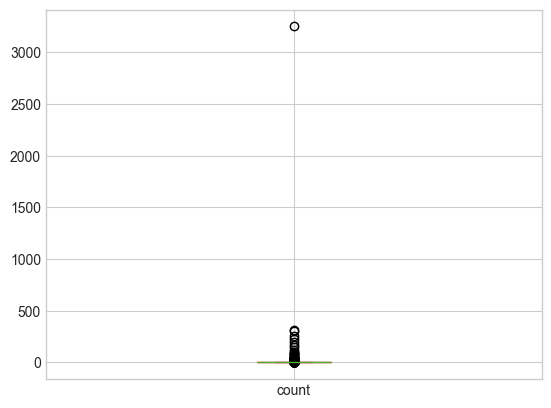

In [11]:
united_df.rename(columns={'שינוי השכר בשקלים': 'salary_change', 
                        'TeurGroupHscm': 'contract_type',
                        'EMP_Matzav_Mishpachti': 'marital_status'}, inplace=True)
united_df['salary_change'].value_counts().sort_index().plot(kind='box')

In [29]:
# Turn columns to correct data types
united_df = united_df.astype({'aziva_kod': 'int64', 'aziva_year': 'int64',
                              'Semel_Yishuv': 'int64', 'Seif': 'int64', 'Maamad': 'int64',
                              'tafkidCode': 'int64', 'manager_Code': 'int64', 'leave_ind': 'int64',
                              'salary_change': 'int64', 'count_managers': 'int64'})

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer: Error while type casting for column 'aziva_kod'

In [11]:
# Data types and info
print("Data Types Summary:")
print(united_df.dtypes.value_counts())
print("\nColumn Details:")
united_df.info()

Data Types Summary:
float64           18
int64             14
object             5
datetime64[ns]     2
Name: count, dtype: int64

Column Details:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16359 entries, 0 to 16358
Data columns (total 39 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   leave_ind       16359 non-null  int64         
 1   fictive_id      16359 non-null  object        
 2   year_date       16359 non-null  int64         
 3   aziva_kod       3201 non-null   float64       
 4   aziva_date      3201 non-null   datetime64[ns]
 5   aziva_year      3201 non-null   float64       
 6   contract_type   14898 non-null  object        
 7   vetek_months    16359 non-null  int64         
 8   age             16359 non-null  int64         
 9   gender          16348 non-null  object        
 10  marital_status  16348 non-null  object        
 11  Yishuv          16171 non-null  object        
 12  Semel_Yishu

In [32]:
# Unique fictive_id count vs. total rows count
unique_fictive_id_count = united_df['fictive_id'].nunique()
total_rows_count = len(united_df)

# For each source count the number of unique fictive_id and total rows
source_counts = united_df.groupby('source').agg(unique_fictive_id_count=('fictive_id', 'nunique'), total_rows_count=('fictive_id', 'count')).reset_index()

# For eahc source count how many leave_ind = 1 and leave_ind = 0
leave_counts = united_df.groupby('source')['leave_ind'].value_counts().unstack(fill_value=0).reset_index().rename(columns={0: 'leave_ind_0_count', 1: 'leave_ind_1_count'})

print(f"Total unique employee count: {unique_fictive_id_count}")
print(f"Total row count: {total_rows_count}")
print(f"Ratio: {total_rows_count / unique_fictive_id_count:.2}")
print("\nUnique employee count and total row count by source:")
print(source_counts)
print("\nLeave indicator counts by source:")
print(leave_counts)

Total unique employee count: 4700
Total row count: 16359
Ratio: 3.5

Unique employee count and total row count by source:
   source  unique_fictive_id_count  total_rows_count
0       1                     1296              4420
1       2                     2611              8792
2       3                      793              3147

Leave indicator counts by source:
leave_ind  source  leave_ind_0_count  leave_ind_1_count
0               1               4074                346
1               2               8094                698
2               3               2994                153


## 🎲 Smart Sampling & Bagging Ensemble Strategy

* **Source Distributions & Churn Rates:**
  * **Train Sources (1 & 2):** Highly consistent Churn rates (~7.83% and ~7.94% respectively), providing a balanced and aligned target distribution during the bootstrapping phase.
  * **Validation Source (3):** Exhibits a lower Churn rate (~4.86%). This baseline shift serves as a rigorous, conservative hold-out test set to ensure the final model generalizes well under stricter class imbalance.

### ⚠️ Row-Level Bootstrapping Warning
* **Do NOT use standard row-level bootstrapping.** Since employees have multiple rows over time (Panel Data, ~3.5 rows per ID), independent row sampling breaks temporal dependencies and causes severe data leakage.

### ⚙️ Implementation: Group-Stratified Bagging Ensemble
1. **Group by Employee:** Bootstrapping must sample at the **Employee level (`fictive_id`)**. When an employee is selected, *all* of their historical rows must be pulled together into the resampled dataset.
2. **Stratification Targets:** Prior to sampling, label each unique employee in the training set (Sources 1 & 2) based on a composite key: `[Source_EverLeft]`. Sample with replacement from within these distinct strata to perfectly preserve class and source ratios across all bootstrap folds.
3. **Ensemble Architecture:** Train an ensemble of $K$ independent base estimators (e.g., `XGBoost`). The final prediction will be computed using **Soft Voting** (averaging predicted probabilities across all $K$ models).
4. **Strict Validation Safeguard:** Source 3 (793 unique employees, 3,147 rows) must remain entirely untouched during the bootstrapping process. It serves strictly as an **External Hold-Out Validation Set** to evaluate the final ensemble's generalization capability.



Columns with missing values: 23


,Missing Count,Missing %
aziva_kod,13158,80.43
aziva_date,13158,80.43
aziva_year,13158,80.43
salary_change,8097,49.50
Median_Payment,6631,40.53
stdevp_Payment,6631,40.53
avg_Payment,6631,40.53
tafkidCode,2184,13.35
manager_Code,1733,10.59
count_managers,1730,10.58


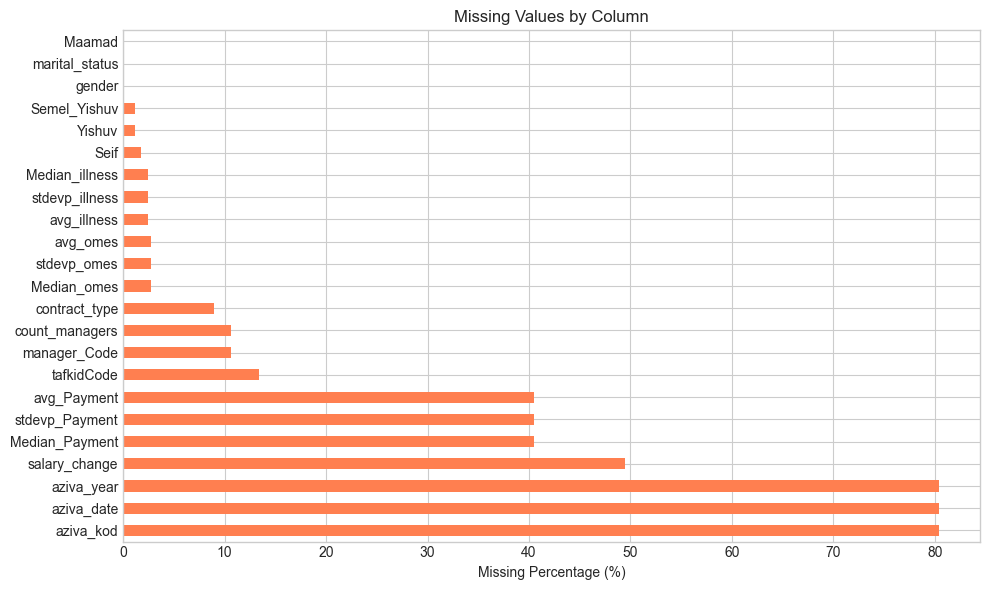

In [19]:
# Missing values analysis
missing = united_df.isnull().sum()
missing_pct = (missing / len(united_df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f"Columns with missing values: {len(missing_df)}")
display(missing_df)

# Visualize missing values
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

Number of rows where ALL payment columns are missing together: 6631
Total expected missing for each: 6631

Number of rows where BOTH salary_change AND all payment columns are missing: 6631


<Figure size 1000x600 with 0 Axes>

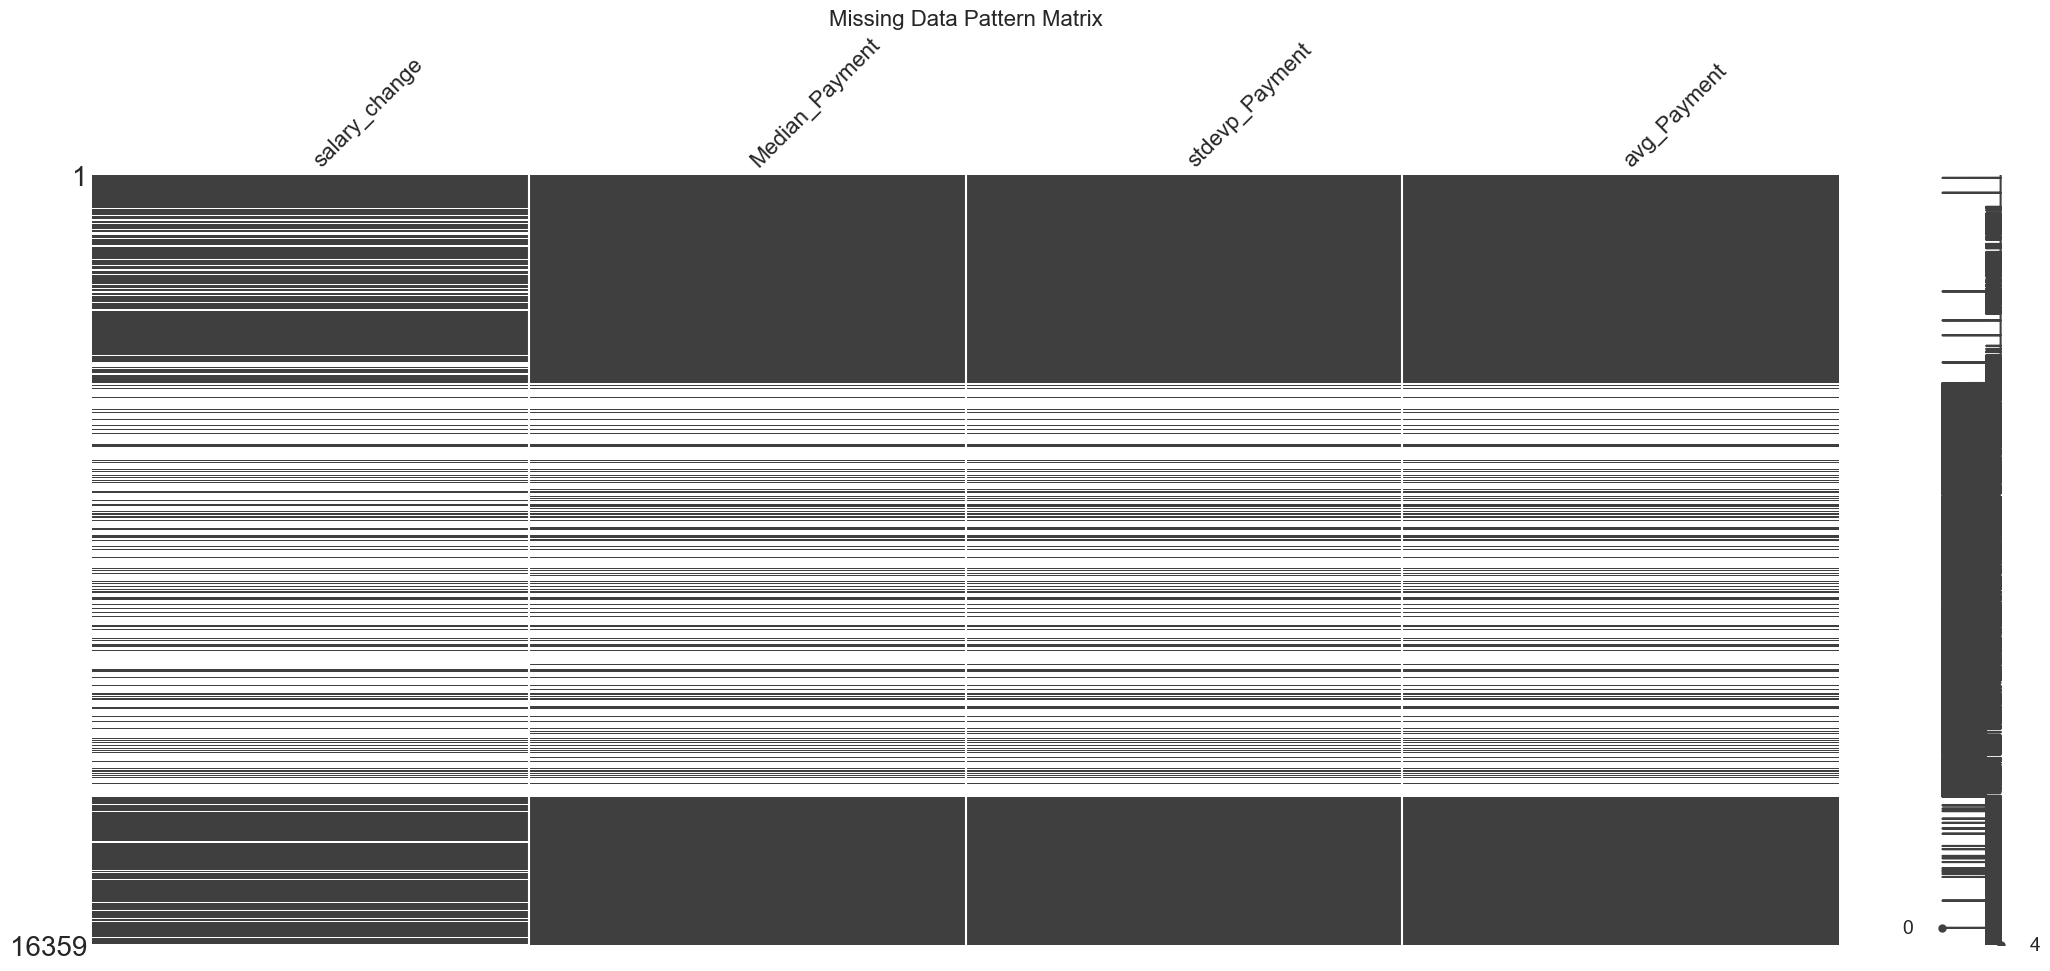

In [20]:
payment_cols = ['Median_Payment', 'stdevp_Payment', 'avg_Payment']
all_target_cols = ['salary_change'] + payment_cols

# Check if the missing rows for payment columns overlap perfectly
# We count how many rows are missing across ALL specified payment columns simultaneously
perfect_overlap = united_df[payment_cols].isnull().all(axis=1).sum()
print(f"Number of rows where ALL payment columns are missing together: {perfect_overlap}")
print(f"Total expected missing for each: 6631\n")

# Check the intersection between salary_change missingness and payment missingness
salary_and_payment_missing = united_df[united_df['salary_change'].isnull()][payment_cols].isnull().all(axis=1).sum()
print(f"Number of rows where BOTH salary_change AND all payment columns are missing: {salary_and_payment_missing}")

# Visualize the missingness pattern using a matrix plot
# This helps identify if data is missing in a monotone or structural pattern
plt.figure(figsize=(10, 6))
msno.matrix(united_df[all_target_cols])
plt.title("Missing Data Pattern Matrix", fontsize=16)
plt.show()

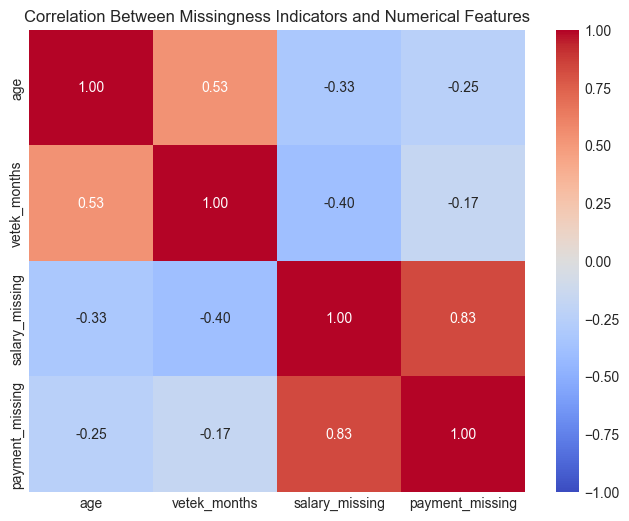

In [21]:
# Create binary indicators: 1 if missing, 0 if present
united_df['salary_missing'] = united_df['salary_change'].isnull().astype(int)
united_df['payment_missing'] = united_df['avg_Payment'].isnull().astype(int)

# Let's check correlation with other numerical variables in your dataset
# Replace ['age', 'tenure'] with actual numerical columns present in your data
numerical_features = ['age', 'vetek_months'] 
features_to_check = numerical_features + ['salary_missing', 'payment_missing']

# Calculate Spearman correlation matrix (handles non-linear and binary relationships better)
corr_matrix = united_df[features_to_check].corr(method='spearman')

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Between Missingness Indicators and Numerical Features")
plt.show()



In [22]:
# For Categorical Features (e.g., 'department'): check missingness percentage per category
# Replace 'department' with your actual categorical features
categorical_col = 'source'
if categorical_col in united_df.columns:
    missing_by_cat = united_df.groupby(categorical_col)[['salary_missing', 'payment_missing']].mean() * 100
    print(f"\nPercentage of missing values across different categories of '{categorical_col}':")
    print(missing_by_cat)


Percentage of missing values across different categories of 'source':
        salary_missing  payment_missing
source                                 
1            17.058824         0.180995
2            78.662420        75.113740
3            13.568478         0.603750


In [23]:
united_df.columns

Index(['leave_ind', 'fictive_id', 'year_date', 'aziva_kod', 'aziva_date',
       'aziva_year', 'contract_type', 'vetek_months', 'age', 'gender',
       'marital_status', 'Yishuv', 'Semel_Yishuv', 'Seif', 'Maamad',
       'tafkidCode', 'manager_Code', 'calc_month', 'Tafkid', 'Maneger',
       'Mahala', 'Distance', 'WorkHours', 'Sahar', 'MZV_Flag', 'hedrut',
       'children', 'avg_Payment', 'stdevp_Payment', 'Median_Payment',
       'salary_change', 'avg_illness', 'stdevp_illness', 'Median_illness',
       'avg_omes', 'stdevp_omes', 'Median_omes', 'count_managers', 'source',
       'salary_missing', 'payment_missing'],
      dtype='object')

Column 'salary_change' - Skewness: -0.959


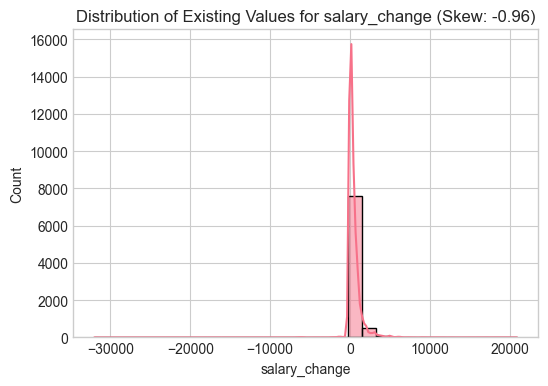

Column 'Median_Payment' - Skewness: 1.998


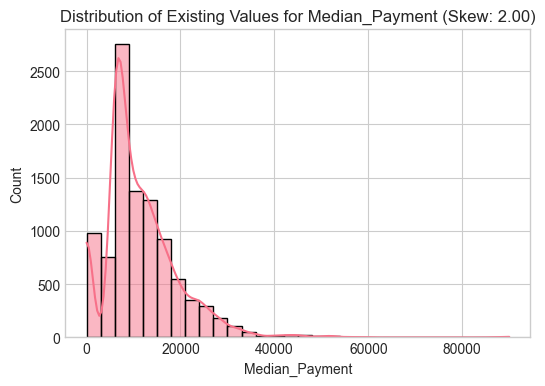

Column 'stdevp_Payment' - Skewness: 9.116


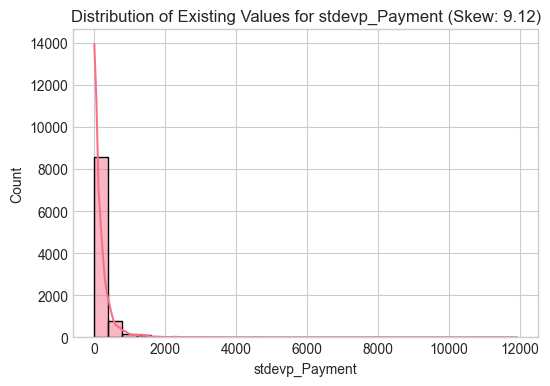

Column 'avg_Payment' - Skewness: 1.999


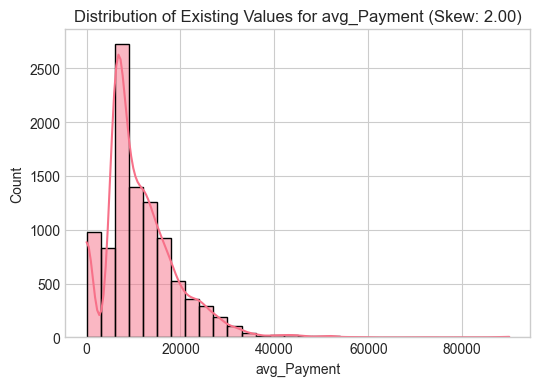

In [24]:
from scipy.stats import skew

for col in all_target_cols:
    # Drop missing values to analyze the existing distribution
    valid_data = united_df[col].dropna()
    
    # Calculate skewness
    # Skewness > 1 or < -1 indicates a highly skewed distribution
    col_skew = skew(valid_data)
    print(f"Column '{col}' - Skewness: {col_skew:.3f}")
    
    # Plot histogram with a Kernel Density Estimate (KDE)
    plt.figure(figsize=(6, 4))
    sns.histplot(valid_data, kde=True, bins=30)
    plt.title(f"Distribution of Existing Values for {col} (Skew: {col_skew:.2f})")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 🛠️ Data Preprocessing & Modeling Strategy for Missing Values

### 1. Missingness Insights (EDA Summary)
* **Structural Missingness:** $100\%$ overlap ($6,631$ rows) across all `Payment` variables (`avg_Payment`, `Median_Payment`, `stdevp_Payment`) and `salary_change`.
* **Mechanism:** Not MCAR. Highly correlated with short tenure (`vetek_months`), meaning missing values structurally represent **new employees** who haven't accumulated salary history yet.
* **Skewness:** High positive skewness in payments (`avg`/`Median` ~ 2.00, `stdevp` ~ 9.12) and negative skewness in `salary_change` (~ -0.96).

---

### 2. Feature Engineering (Mandatory)
* **Create Missingness Indicators:** Ensure `payment_missing` (and/or `salary_missing`) are included as binary features ($1$ for missing, $0$ for present). They capture critical structural information (New Employee status) for Churn prediction.

---

### 3. Model-Specific Strategies (Before Training)

#### 🌲 Tree-Based Models (`XGBoost`, `RandomForest`)
* **Strategy:** **Do NOT impute.** Leave missing values as `NaN`.
* **Why:** Tree models handle missing values natively. `XGBoost` will learn the optimal split direction for `NaN` automatically, preserving the clean structural boundary of new employees without adding artificial noise.

#### 📈 Linear Models (`Logistic Regression`)
* **Strategy:** **Imputation is required** (`NaN` will cause execution failure).
* **Options:**
  1. **Zero Imputation:** Replace `NaN` with `0` for payment/salary change features (logically sound since no payments occurred yet), relying on `payment_missing=1` to adjust the intercept.
  2. **Tree-Based Imputation:** Use `IterativeImputer(estimator=ExtraTreesRegressor())` to handle the extreme skewness if predictive imputation is preferred over zero-filling.
* **Scaling/Transformation:** Apply Log-transformation ($\log(x+1)$) to continuous payment features to handle the severe skewness before feeding them into the logistic model.

---

### 4. Feature Selection Checklist
* **Drop (Identifiers / Data Leakage):** `fictive_id`, `year_date`, `aziva_date` (Target leak!), `aziva_year`, `aziva_kod`, `calc_month`, `source`.
* **Encode (Categorical):** `contract_type`, `gender`, `marital_status`, `Tafkid`, `Mahala`, `Maamad`. Use `Distance` instead of `Yishuv` to prevent high-cardinality overfitting.

## 2. Target Variable Analysis

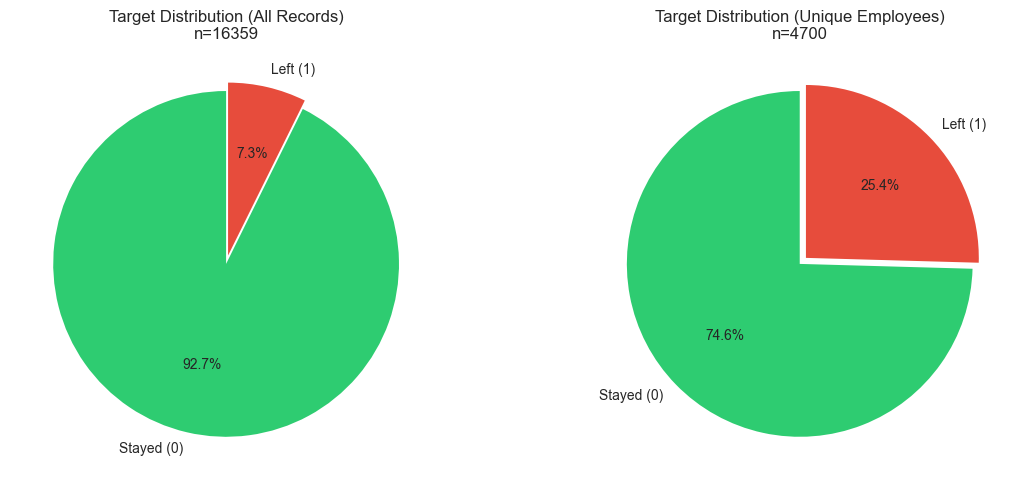

In [25]:
# Target distribution (per record)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Per record
target_counts = united_df['leave_ind'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(target_counts, labels=['Stayed (0)', 'Left (1)'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[0].set_title(f'Target Distribution (All Records)\nn={len(united_df)}')

# Per unique employee
emp_target = united_df.sort_values(by='calc_month').groupby('fictive_id')['leave_ind'].last()
emp_counts = emp_target.value_counts()
axes[1].pie(emp_counts, labels=['Stayed (0)', 'Left (1)'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[1].set_title(f'Target Distribution (Unique Employees)\nn={len(emp_target)}')

plt.tight_layout()
plt.show()

<Axes: xlabel='aziva_kod'>

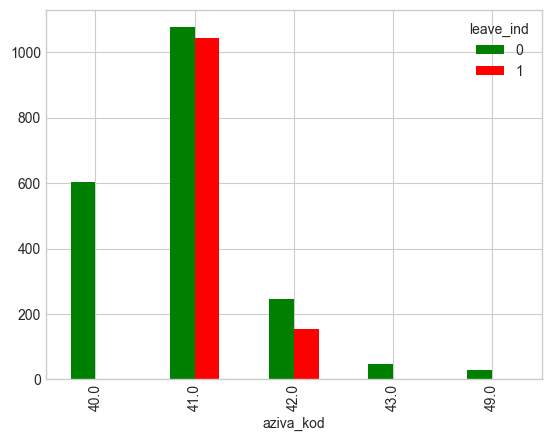

In [26]:
pd.crosstab(united_df['aziva_kod'], united_df['leave_ind']).plot(
    kind='bar', 
    color=['green', 'red']
)

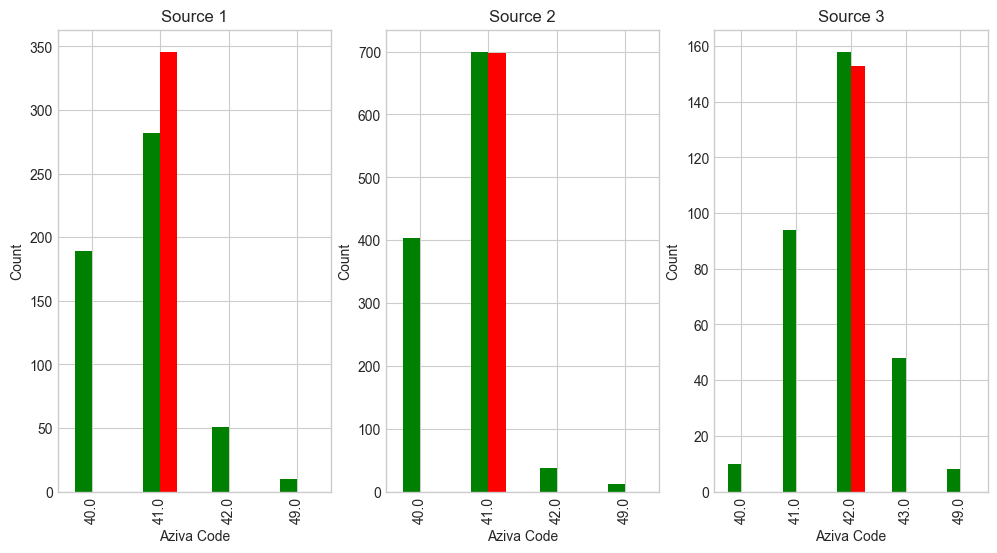

In [27]:
# Check of each source the leave_ind distribution per aziva_code
fig = plt.figure(figsize=(12, 6))
for i, source in enumerate(united_df['source'].unique(), start=1):
    plt.subplot(1, 3, i)
    subset = united_df[united_df['source'] == source]
    pd.crosstab(subset['aziva_kod'], subset['leave_ind']).plot(
        kind='bar', 
        color=['green', 'red'], 
        ax=plt.gca(), 
        legend=False
    )
    plt.title(f'Source {source}')
    plt.xlabel('Aziva Code')
    plt.ylabel('Count')

Should be only 42 (resigned) as leave_ind = 1

In [21]:
# Pust 0 in leave_ind where aziva_kod is != 42, else 1
updated_df = united_df.copy()
updated_df['leave_ind'] = updated_df['aziva_kod'].apply(lambda x: 1 if x == 42 else 0)

41-פיטורין, fired \
43-פרישה, retirement \
49-נפטר, deceased \
42-התפטרות, resignation \
40-סיום עבודה, termination \

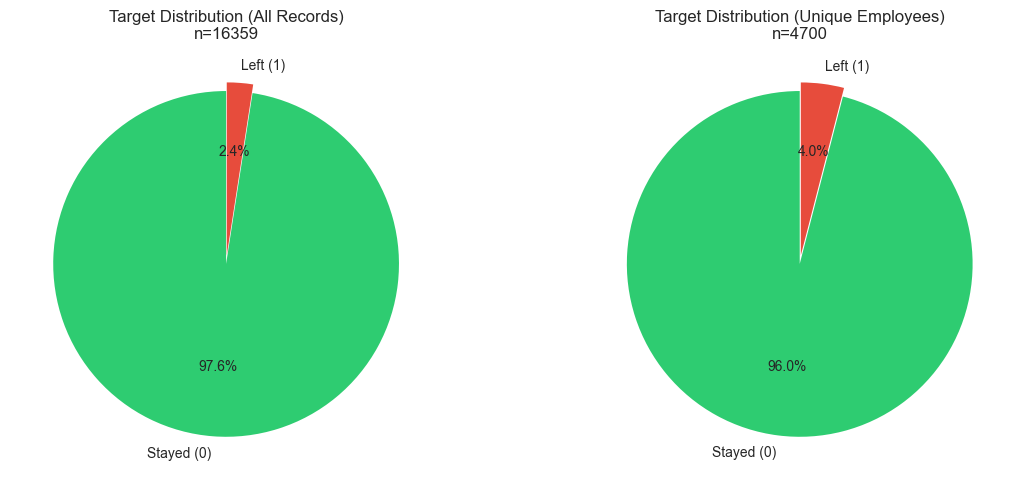

In [22]:
# Target distribution (per record)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Per record
target_counts = updated_df['leave_ind'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(target_counts, labels=['Stayed (0)', 'Left (1)'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[0].set_title(f'Target Distribution (All Records)\nn={len(updated_df)}')

# Per unique employee
emp_target = updated_df.sort_values(by='calc_month').groupby('fictive_id')['leave_ind'].last()
emp_counts = emp_target.value_counts()
axes[1].pie(emp_counts, labels=['Stayed (0)', 'Left (1)'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[1].set_title(f'Target Distribution (Unique Employees)\nn={len(emp_target)}')

plt.tight_layout()
plt.show()

## ⚖️ Handling Imbalanced Data (Churn Class Balance)

### Practical Modeling Recommendations

#### ⚙️ Algorithmic Weighting (Preferred over Resampling)
* **XGBoost:** Set the `scale_pos_weight` parameter. 
  $$\text{scale\_pos\_weight} = \frac{\text{Total Number of Negative Instances (Stayed)}}{\text{Total Number of Positive Instances (Left)}}$$
* **Random Forest & Logistic Regression:** Set the parameter `class_weight='balanced'`. This automatically adjusts weights inversely proportional to class frequencies.

#### 📊 Evaluation Metrics Strategy
* **Do NOT use Accuracy:** Accuracy is highly misleading for imbalanced churn data (e.g., $95\%$ accuracy looks good but might catch $0\%$ of leavers).
* **Key Metrics to Track:** Focus entirely on **F1-Score**, **Precision-Recall AUC (PR-AUC)**, and **Recall** (to maximize the detection of employees at risk of leaving).

<Axes: xlabel='aziva_kod'>

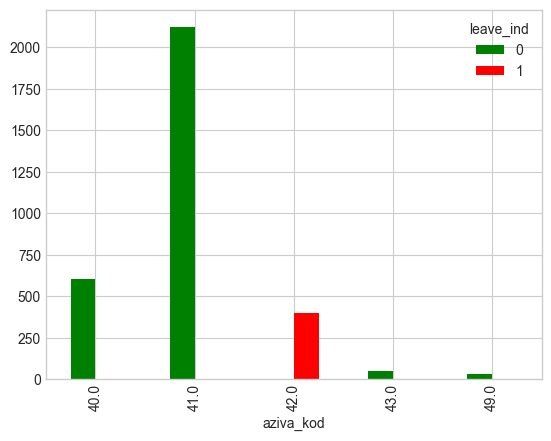

In [23]:
pd.crosstab(updated_df['aziva_kod'], updated_df['leave_ind']).plot(
    kind='bar', 
    color=['green', 'red']
)

In [24]:
updated_df.columns

Index(['leave_ind', 'fictive_id', 'year_date', 'aziva_kod', 'aziva_date',
       'aziva_year', 'contract_type', 'vetek_months', 'age', 'gender',
       'marital_status', 'Yishuv', 'Semel_Yishuv', 'Seif', 'Maamad',
       'tafkidCode', 'manager_Code', 'calc_month', 'Tafkid', 'Maneger',
       'Mahala', 'Distance', 'WorkHours', 'Sahar', 'MZV_Flag', 'hedrut',
       'children', 'avg_Payment', 'stdevp_Payment', 'Median_Payment',
       'salary_change', 'avg_illness', 'stdevp_illness', 'Median_illness',
       'avg_omes', 'stdevp_omes', 'Median_omes', 'count_managers', 'source',
       'salary_missing', 'payment_missing'],
      dtype='object')

<Axes: xlabel='Yishuv'>

464

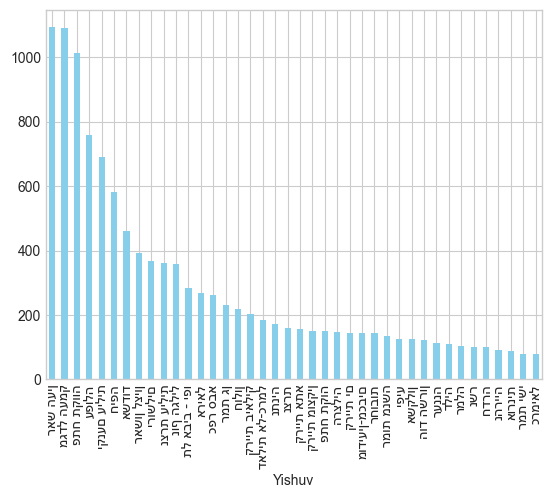

In [25]:
display(updated_df['Yishuv'].value_counts().head(40).plot(kind='bar', color='skyblue'))
len(updated_df['Yishuv'].unique())

In [40]:
updated_df.columns

Index(['leave_ind', 'fictive_id', 'year_date', 'aziva_kod', 'aziva_date',
       'aziva_year', 'vetek_months', 'age', 'Yishuv', 'Semel_Yishuv', 'Seif',
       'Maamad', 'tafkidCode', 'manager_Code', 'calc_month', 'Tafkid',
       'Maneger', 'Mahala', 'Distance', 'WorkHours', 'Sahar', 'MZV_Flag',
       'hedrut', 'children', 'avg_Payment', 'stdevp_Payment', 'Median_Payment',
       'salary_change', 'avg_illness', 'stdevp_illness', 'Median_illness',
       'avg_omes', 'stdevp_omes', 'Median_omes', 'count_managers', 'source',
       'gender_Female', 'gender_Male', 'contract_type_Contractor',
       'contract_type_Global', 'contract_type_Hourly', 'contract_type_Monthly',
       'marital_status_Divorced', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed'],
      dtype='object')

In [35]:
display(updated_df['Distance'].value_counts())
# Drop 'Distance' column - only 1 unique value
updated_df.drop(columns=['Distance'], inplace=True)

Distance
0    16359
Name: count, dtype: int64

### Notice: 'Distance' column has only one unique value (0), check with Elad if it's a mistake or if we can drop it.
### Needs to be 'distance_to_work' as a numerical feature and not a Flag

In [36]:
flag_columns_boolean = ['Tafkid', 'Maneger', 'Mahala', 'WorkHours', 'Sahar', 'MZV_Flag','hedrut', 'children']
for col in flag_columns_boolean:
    # display(updated_df[col].value_counts())
    # Display % of the value counts
    display(updated_df[col].value_counts(normalize=True)*100)

Tafkid
0    84.216639
1    15.783361
Name: proportion, dtype: float64

Maneger
0    84.546733
1    15.453267
Name: proportion, dtype: float64

Mahala
0    90.714591
1     9.285409
Name: proportion, dtype: float64

WorkHours
0    91.179167
1     8.820833
Name: proportion, dtype: float64

Sahar
0    93.856593
1     6.143407
Name: proportion, dtype: float64

MZV_Flag
0    97.487621
1     2.512379
Name: proportion, dtype: float64

hedrut
0    99.669906
1     0.330094
Name: proportion, dtype: float64

children
0    98.404548
1     1.595452
Name: proportion, dtype: float64

In [37]:
# Convert flag columns to boolean (0 and 1)
for col in flag_columns_boolean:
    updated_df[col] = updated_df[col].astype(bool)

In [89]:
updated_df.head()

,leave_ind,fictive_id,year_date,aziva_kod,aziva_date,aziva_year,vetek_months,age,Yishuv,Semel_Yishuv,Seif,Maamad,tafkidCode,manager_Code,calc_month,Tafkid,Maneger,Mahala,WorkHours,Sahar,MZV_Flag,hedrut,children,avg_Payment,stdevp_Payment,Median_Payment,salary_change,avg_illness,stdevp_illness,Median_illness,avg_omes,stdevp_omes,Median_omes,count_managers,source,gender_Female,gender_Male,contract_type_Global,contract_type_Hourly,contract_type_Monthly,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed
3,0,1_1958,2021,41.0,2025-12-19,2025.0,422,60,מגדל העמק,874.0,9001119.0,9.0,NaN,NaN,2021-12-01,False,False,False,False,True,False,False,False,6395.0,0.0,6395.0,0.0,0.00,0.000000,0.0,NaN,NaN,NaN,NaN,1,False,True,False,False,True,False,True,False,False
4,0,1_1958,2024,41.0,2025-12-19,2025.0,458,63,מגדל העמק,874.0,9001119.0,9.0,NaN,5125.0,2024-12-01,False,False,False,False,True,False,False,False,6395.0,0.0,6395.0,0.0,0.00,0.000000,0.0,NaN,NaN,NaN,1.0,1,False,True,False,False,True,False,True,False,False
28,0,1_6215,2025,41.0,2026-03-20,2026.0,353,55,מגדל העמק,874.0,9003910.0,9.0,33.0,7279.0,2025-12-01,False,True,False,False,False,False,False,False,16150.0,0.0,16150.0,0.0,7.07,10.170983,0.0,0.92,0.088677,0.909732,1.0,1,True,False,True,False,False,False,True,False,False
39,0,1_1613,2022,49.0,2025-10-01,2025.0,445,58,Other,9999.0,9001421.0,9.0,NaN,NaN,2022-12-01,False,False,False,False,False,False,False,False,6032.0,0.0,6032.0,0.0,4.22,13.985101,0.0,0.99,0.145894,1.035684,NaN,1,False,True,False,False,True,False,False,False,True
40,0,1_1903,2022,41.0,2025-10-16,2025.0,435,57,מגדל העמק,874.0,9001812.0,9.0,NaN,NaN,2022-12-01,False,False,False,False,True,False,False,False,11235.0,0.0,11235.0,0.0,3.77,8.818478,0.0,0.92,0.100282,0.926113,NaN,1,False,True,True,False,False,True,False,False,False


## 3. Numerical Features Analysis

In [38]:
'distance_to_work' in df1.columns

False

In [39]:
first_file = pd.read_excel('data\\raw\\first_file.xlsx')
'distance_to_work' in first_file.columns

True

In [51]:
updated_df.columns

Index(['leave_ind', 'fictive_id', 'year_date', 'aziva_kod', 'aziva_date',
       'aziva_year', 'vetek_months', 'age', 'Yishuv', 'Semel_Yishuv', 'Seif',
       'Maamad', 'tafkidCode', 'manager_Code', 'calc_month', 'Tafkid',
       'Maneger', 'Mahala', 'WorkHours', 'Sahar', 'MZV_Flag', 'hedrut',
       'children', 'avg_Payment', 'stdevp_Payment', 'Median_Payment',
       'salary_change', 'avg_illness', 'stdevp_illness', 'Median_illness',
       'avg_omes', 'stdevp_omes', 'Median_omes', 'count_managers', 'source',
       'gender_Female', 'gender_Male', 'contract_type_Contractor',
       'contract_type_Global', 'contract_type_Hourly', 'contract_type_Monthly',
       'marital_status_Divorced', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed'],
      dtype='object')

In [40]:
# Key numerical features
numeric_cols = ['vetek_months', 'age', 'avg_Payment', 'stdevp_Payment', 'Median_Payment',
                'avg_illness', 'stdevp_illness', 'Median_illness', 'avg_omes', 'stdevp_omes', 'Median_omes',
                'count_managers', 'salary_change']

# Summary statistics
print("Numerical Features Summary Statistics:")
updated_df[numeric_cols].describe().round(2)

Numerical Features Summary Statistics:


,vetek_months,age,avg_Payment,stdevp_Payment,Median_Payment,avg_illness,stdevp_illness,Median_illness,avg_omes,stdevp_omes,Median_omes,count_managers,salary_change
count,16359.00,16359.00,9728.00,9728.00,9728.00,15953.00,15953.00,15953.00,15911.00,15911.00,15911.00,14629.00,8262.00
mean,91.09,43.34,11443.15,172.85,11472.71,3.16,5.72,0.73,0.96,0.13,1.00,0.77,443.93
std,99.39,12.21,8253.78,382.31,8280.93,5.15,8.32,2.76,0.17,0.08,0.16,1.23,999.01
min,0.00,16.00,0.00,0.00,0.00,-14.80,0.00,0.00,0.00,0.00,0.00,0.00,-32000.00
25%,18.00,34.00,6413.00,0.00,6450.00,0.00,0.00,0.00,0.89,0.09,0.92,0.00,0.00
50%,53.00,43.00,9600.00,25.98,9600.00,0.83,1.66,0.00,0.96,0.12,0.99,0.00,200.00
75%,131.00,52.00,15000.00,216.51,15000.00,4.53,9.23,0.00,1.05,0.16,1.08,1.00,600.00
max,584.00,95.00,90000.00,11925.70,90000.00,74.11,84.93,50.10,2.19,3.35,2.22,11.00,20878.00


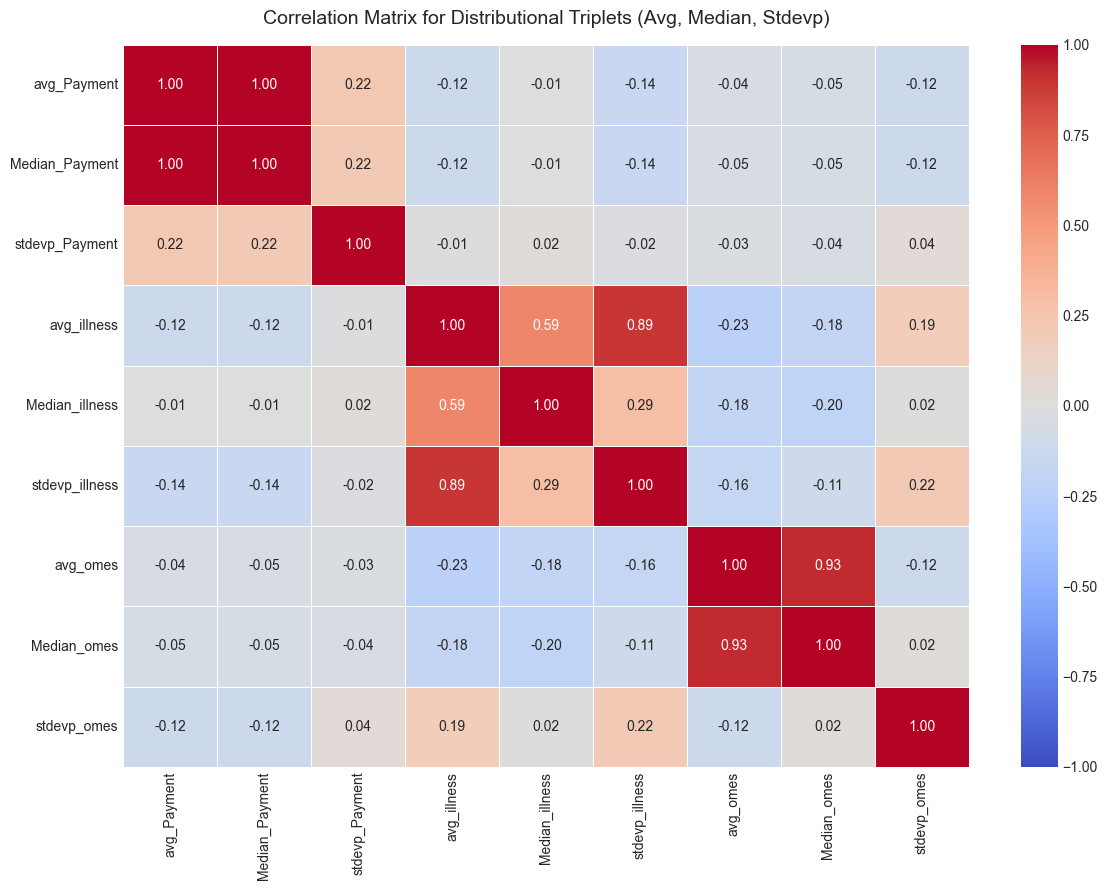

--- High Multicollinearity Check (Avg vs Median) ---
Payment Domain: Correlation between avg_Payment and Median_Payment is 1.000
   ⚠️ WARNING: Severe multicollinearity detected in Payment. Consider dropping 'avg' for Logistic Regression.
Illness Domain: Correlation between avg_illness and Median_illness is 0.593
Omes Domain: Correlation between avg_omes and Median_omes is 0.926
   ⚠️ WARNING: Severe multicollinearity detected in Omes. Consider dropping 'avg' for Logistic Regression.


In [41]:
# 1. Define the lists of features for each domain
payment_features = ['avg_Payment', 'Median_Payment', 'stdevp_Payment']
illness_features = ['avg_illness', 'Median_illness', 'stdevp_illness']
omes_features    = ['avg_omes', 'Median_omes', 'stdevp_omes']

all_triplet_features = payment_features + illness_features + omes_features

# 2. Calculate the Pearson correlation matrix (drop missing values for accurate pairwise comparison)
corr_matrix = updated_df[all_triplet_features].corr(method='pearson')

# 3. Plot the correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the correlation numbers inside the squares
    cmap='coolwarm',     # Red for positive correlation, blue for negative
    fmt=".2f",           # Round numbers to 2 decimal places
    vmin=-1, vmax=1,     # Force bounds between -1 and 1
    linewidths=0.5       # Add slight grid lines between blocks
)

plt.title("Correlation Matrix for Distributional Triplets (Avg, Median, Stdevp)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 4. Quick printout to check severe Multicollinearity (Correlation > 0.85) between Avg and Median
print("--- High Multicollinearity Check (Avg vs Median) ---")
for domain, features in [('Payment', payment_features), ('Illness', illness_features), ('Omes', omes_features)]:
    avg_med_corr = corr_matrix.loc[features[0], features[1]]
    print(f"{domain} Domain: Correlation between {features[0]} and {features[1]} is {avg_med_corr:.3f}")
    if abs(avg_med_corr) > 0.85:
         print(f"   ⚠️ WARNING: Severe multicollinearity detected in {domain}. Consider dropping 'avg' for Logistic Regression.")

### 📊 Handling Distributional Triplets (Avg, Median, Stdevp)

#### 🔄 Feature Engineering
* **Coefficient of Variation (CV):** Create `cv_Payment`, `cv_illness`, and `cv_omes` using $\frac{\text{stdevp}}{\text{avg} + 1}$ to measure relative volatility independent of scale.
* **Trend Indicator:** Create `mean_median_diff = avg - Median` to detect short-term spikes or anomalies during the year.

#### 🤖 Model Adaptation

##### 🌲 Tree Models (XGBoost/RF)
* **Strategy:** Keep all 9 original variables intact + add the new engineered features (CV, Diff). 
* **Why:** Tree models are immune to multicollinearity and natively leverage non-linear interactions between mean, median, and variance.

##### 📈 Linear Models (Logistic Regression)
* **Strategy:** Strict feature selection is required due to severe **Multicollinearity** found in the EDA correlation matrix:
  1. **Payment Domain (Perfect $1.00$ correlation):** **Drop** `avg_Payment`. Keep only `Median_Payment` + `cv_Payment`.
  2. **Omes Domain (Severe $0.93$ correlation):** **Drop** `avg_omes`. Keep only `Median_omes` + `cv_omes`.
  3. **Illness Domain (High $0.89$ correlation between Avg & Stdevp):** **Drop** `stdevp_illness`. Keep both `avg_illness` and `Median_illness` (since their correlation is safe at $0.59$).
* **Scaling:** Apply Log-transformation ($\log(x+1)$) followed by `StandardScaler` to all remaining continuous features before training.

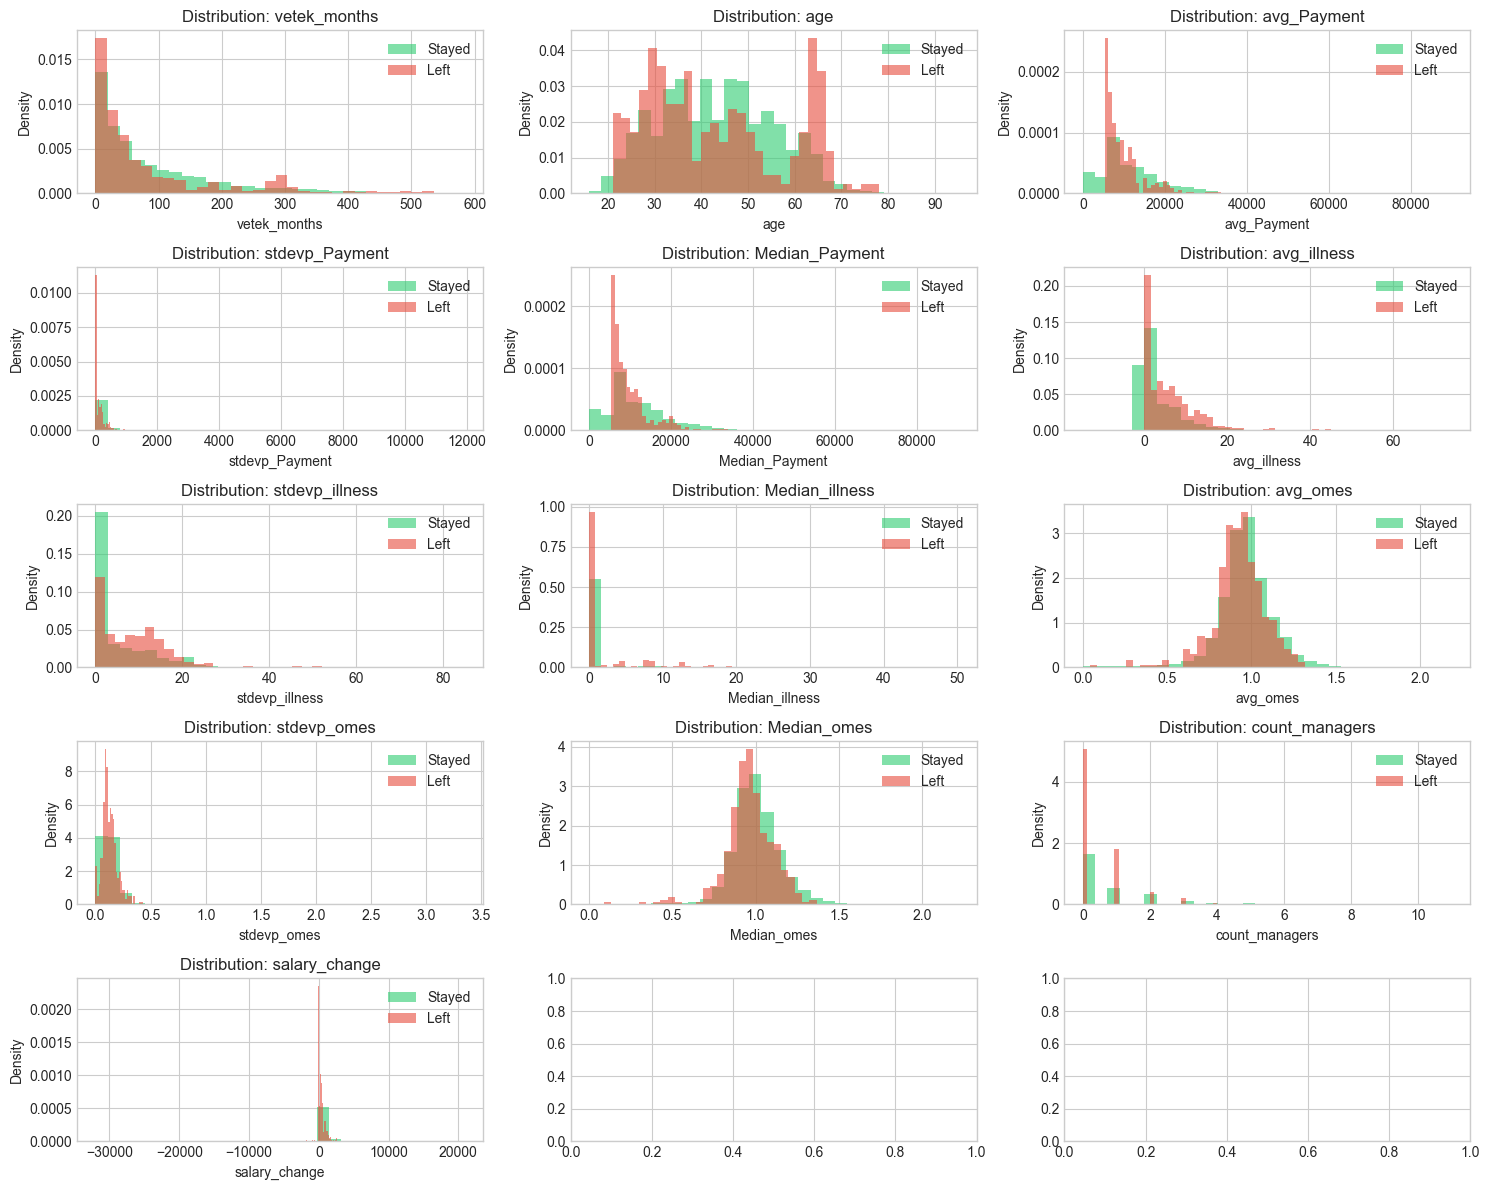

In [42]:
# Distribution plots for key numeric features
fig, axes = plt.subplots(5, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    
    # Plot by target
    for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
        data = updated_df[updated_df['leave_ind'] == target][col].dropna()
        ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
    
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.set_title(f'Distribution: {col}')

plt.tight_layout()
plt.show()

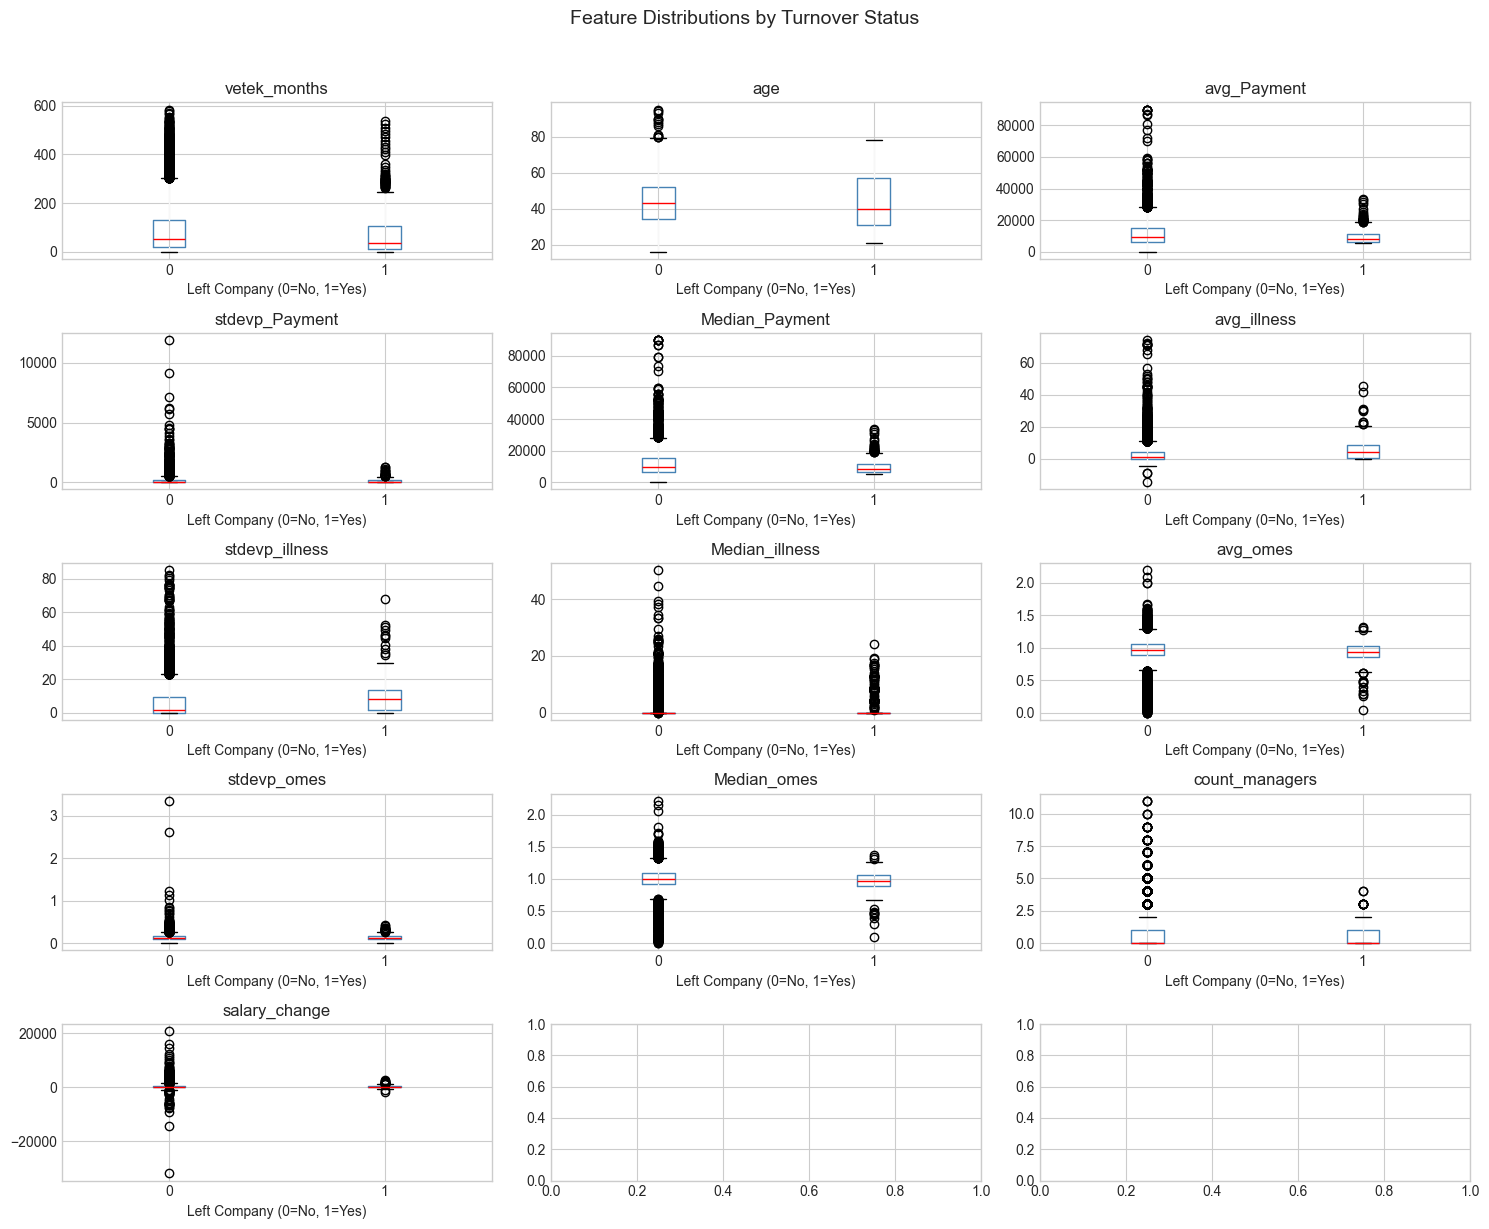

In [43]:
# Box plots comparing features by target
fig, axes = plt.subplots(5, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    updated_df.boxplot(column=col, by='leave_ind', ax=ax, 
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
    ax.set_xlabel('Left Company (0=No, 1=Yes)')
    ax.set_title(col)

plt.suptitle('Feature Distributions by Turnover Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [45]:
# Statistical test: Are features significantly different between groups?
print("Statistical Significance Test (Mann-Whitney U Test)")
print("="*60)

results = []
for col in numeric_cols:
    stayed = updated_df[updated_df['leave_ind'] == 0][col].dropna()
    left = updated_df[updated_df['leave_ind'] == 1][col].dropna()
    
    stat, pval = stats.mannwhitneyu(stayed, left, alternative='two-sided')
    
    results.append({
        'Feature': col,
        'Stayed Mean': stayed.mean(),
        'Left Mean': left.mean(),
        'Difference': left.mean() - stayed.mean(),
        'p-value': pval,
        'Significant': '✓' if pval < 0.05 else '✗'
    })

results_df = pd.DataFrame(results).sort_values('p-value')
display(results_df.round(4))

Statistical Significance Test (Mann-Whitney U Test)


,Feature,Stayed Mean,Left Mean,Difference,p-value,Significant
5,avg_illness,3.0868,5.8497,2.7629,0.0000,✓
6,stdevp_illness,5.6345,9.0889,3.4543,0.0000,✓
7,Median_illness,0.7016,1.9133,1.2117,0.0000,✓
8,avg_omes,0.9657,0.9245,-0.0412,0.0000,✓
10,Median_omes,1.0023,0.9649,-0.0373,0.0000,✓
2,avg_Payment,11513.1220,9693.1005,-1820.0215,0.0000,✓
4,Median_Payment,11542.1243,9736.6444,-1805.4799,0.0000,✓
11,count_managers,0.7755,0.4490,-0.3264,0.0000,✓
0,vetek_months,91.2343,85.3825,-5.8518,0.0008,✓
1,age,43.3476,43.2075,-0.1401,0.2479,✗


### 🔬 Statistical Significance Insights (Mann-Whitney U Test)

* **High Discriminative Power:** Most distributional features (`Payment`, `illness`, and `omes` averages and medians) show extreme significance ($p = 0.0000$), providing a strong signal for Churn.
* **Key Behavioral Patterns:**
  * **Illness:** Leavers show nearly **double** the average, median, and volatility (`stdevp`) of sick days, indicating high burnout or disengagement.
  * **Level vs. Volatility:** For `Payment` and `omes`, the absolute baseline matters (Leavers have lower salary/workload medians), but the within-year volatility (`stdevp`) does not significantly differ between groups ($p > 0.40$).
* **Non-Significant Features:** `age` ($p=0.24$), `stdevp_omes` ($p=0.41$), `stdevp_Payment` ($p=0.51$), and `salary_change` ($p=0.99$).

#### 🤖 Modeling Action Plan
* **Tree Models (XGBoost/RF):** **Keep all features.** Even univariate non-significant features like `salary_change` or `stdevp_Payment` can provide high value when combined non-linearly with tenure (`vetek_months`) or missingness indicators.
* **Linear Models (Logistic Regression):** **Drop** the non-significant features (`stdevp_Payment`, `stdevp_omes`, `salary_change`, `age`) to reduce noise, prevent inflation of coefficients, and focus solely on the high-signal linear features (`Median_Payment`, `avg_illness`, etc.).

## 4. Categorical Features Analysis

<Axes: xlabel='Yishuv'>

464

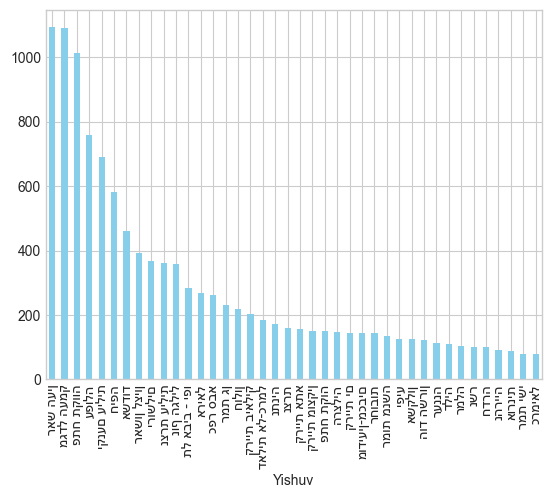

In [ ]:
display(updated_df['Yishuv'].value_counts().head(40).plot(kind='bar', color='skyblue'))
len(updated_df['Yishuv'].unique())

In [ ]:
9999 in updated_df['Semel_Yishuv'].unique()

False

In [ ]:
# unify 'Yishuv' less than 10 or equal to NaN to 'Other'
updated_df['Yishuv'] = updated_df['Yishuv'].apply(lambda x: x if updated_df['Yishuv'].value_counts()[x] >= 10 else 'Other')
updated_df['Yishuv'] = updated_df['Yishuv'].fillna('Other')

# Update 'Semel_Yishuv' where 'Yishuv' is 'Other' to 9999
updated_df.loc[updated_df['Yishuv'] == 'Other', 'Semel_Yishuv'] = 9999

KeyError: nan

In [ ]:
updated_df['gender'].value_counts().head(40)##.plot(kind='bar', color='skyblue')

gender
זכר     8026
נקבה    3902
גבר     2320
אישה    2100
Name: count, dtype: int64

In [ ]:
# change 'gender' into 2 categories in English instead of 4: 'Male' and 'Female'. 
# 'זכר' will be mapped to 'Male' and 'נקבה' will be mapped to 'Female'
updated_df['gender'] = updated_df['gender'].replace({'זכר': 'Male',
                                                     'נקבה': 'Female',
                                                     'גבר': 'Male',
                                                     'אישה': 'Female'})

In [ ]:
updated_df['contract_type'].unique()

array(['חודשי', 'גלובלי', nan, 'שעתי', 'חודשי גלובלי', 'עובד חיצוני'],
      dtype=object)

In [ ]:
updated_df.groupby('contract_type')[['avg_Payment', 'Median_Payment']].mean()

,avg_Payment,Median_Payment
contract_type,,
גלובלי,17815.607662,17875.073576
חודשי,6830.197926,6855.025993
חודשי גלובלי,15975.549472,15959.173392
עובד חיצוני,NaN,NaN
שעתי,3672.047194,3688.560394


In [ ]:
len(updated_df[updated_df['contract_type'] =='עובד חיצוני'])

2

In [ ]:
# Change 'contract_type' to English and unify 'חודשי גלובלי' to 'גלובלי' since they are the same contract type
updated_df['contract_type'] = updated_df['contract_type'].replace({
    'גלובלי': 'Global',
    'חודשי': 'Monthly',
    'חודשי גלובלי': 'Global',
    'עובד חיצוני': 'Contractor',
    'שעתי': 'Hourly' 
})

In [ ]:
updated_df['marital_status'].unique()

array(['נשוי/נשואה', 'גרוש/ה', 'אלמן/ה', 'רווק/ה', nan], dtype=object)

In [ ]:
updated_df['marital_status'] = updated_df['marital_status'].replace({
    'נשוי/נשואה': 'Married',
    'רווק/ה': 'Single',
    'גרוש/ה': 'Divorced',
    'אלמן/ה': 'Widowed'
})

In [ ]:
# change columns to be one hot encoded
hot_encoding_col = ['gender', 'contract_type', 'marital_status']

cols_to_encode = [c for c in hot_encoding_col if c in updated_df.columns]
if cols_to_encode:
    updated_df = pd.get_dummies(updated_df, columns=cols_to_encode)
else:
    print(f"No columns to encode found in updated_df among: {hot_encoding_col}")

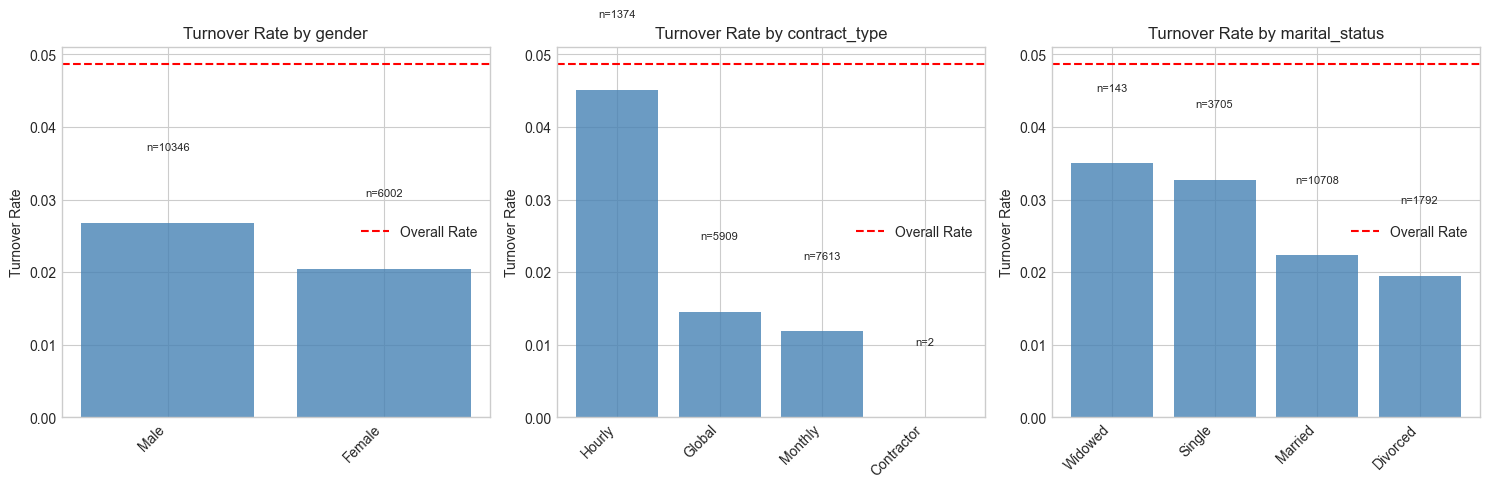

In [47]:
# Categorical features
cat_cols = ['gender', 'contract_type', 'marital_status']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    # Calculate turnover rate by category
    turnover_rate = updated_df.groupby(col)['leave_ind'].mean().sort_values(ascending=False)
    counts = updated_df.groupby(col).size()
    
    bars = ax.bar(range(len(turnover_rate)), turnover_rate.values, color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(turnover_rate)))
    ax.set_xticklabels(turnover_rate.index, rotation=45, ha='right')
    ax.set_ylabel('Turnover Rate')
    ax.set_title(f'Turnover Rate by {col}')
    ax.axhline(y=df['leave_ind'].mean(), color='red', linestyle='--', label='Overall Rate')
    ax.legend()
    
    # Add count labels
    for j, (bar, idx) in enumerate(zip(bars, turnover_rate.index)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'n={counts[idx]}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

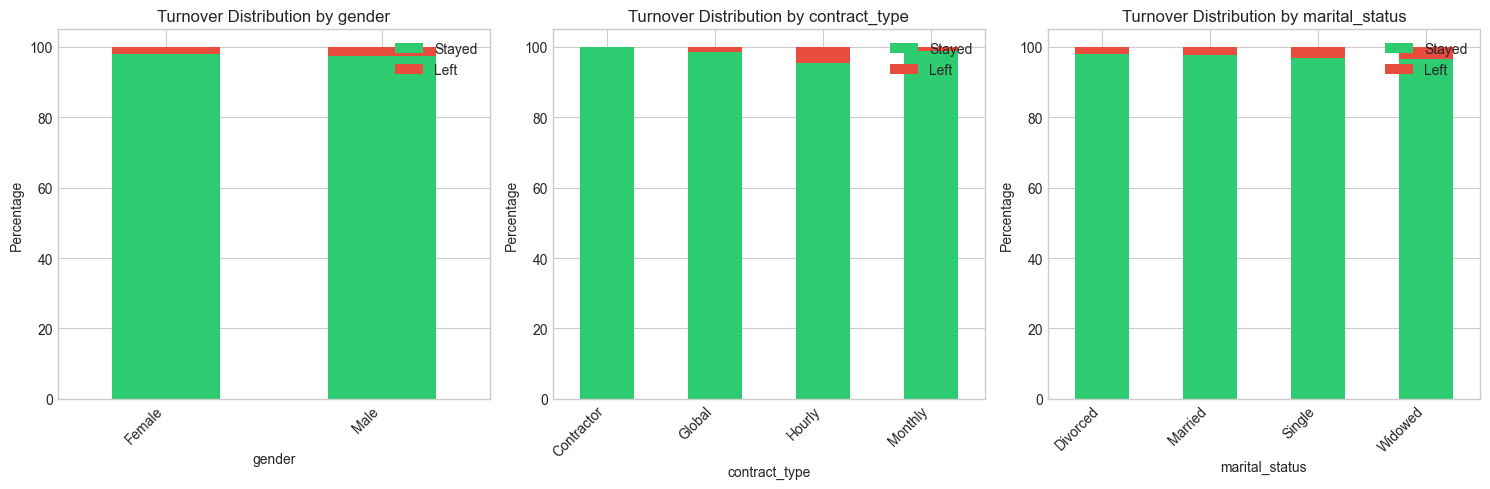

In [48]:
# Detailed breakdown with stacked bars
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    cross_tab = pd.crosstab(updated_df[col], updated_df['leave_ind'], normalize='index') * 100
    cross_tab.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
    
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage')
    ax.set_title(f'Turnover Distribution by {col}')
    ax.legend(['Stayed', 'Left'], loc='upper right')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 5. Correlation Analysis

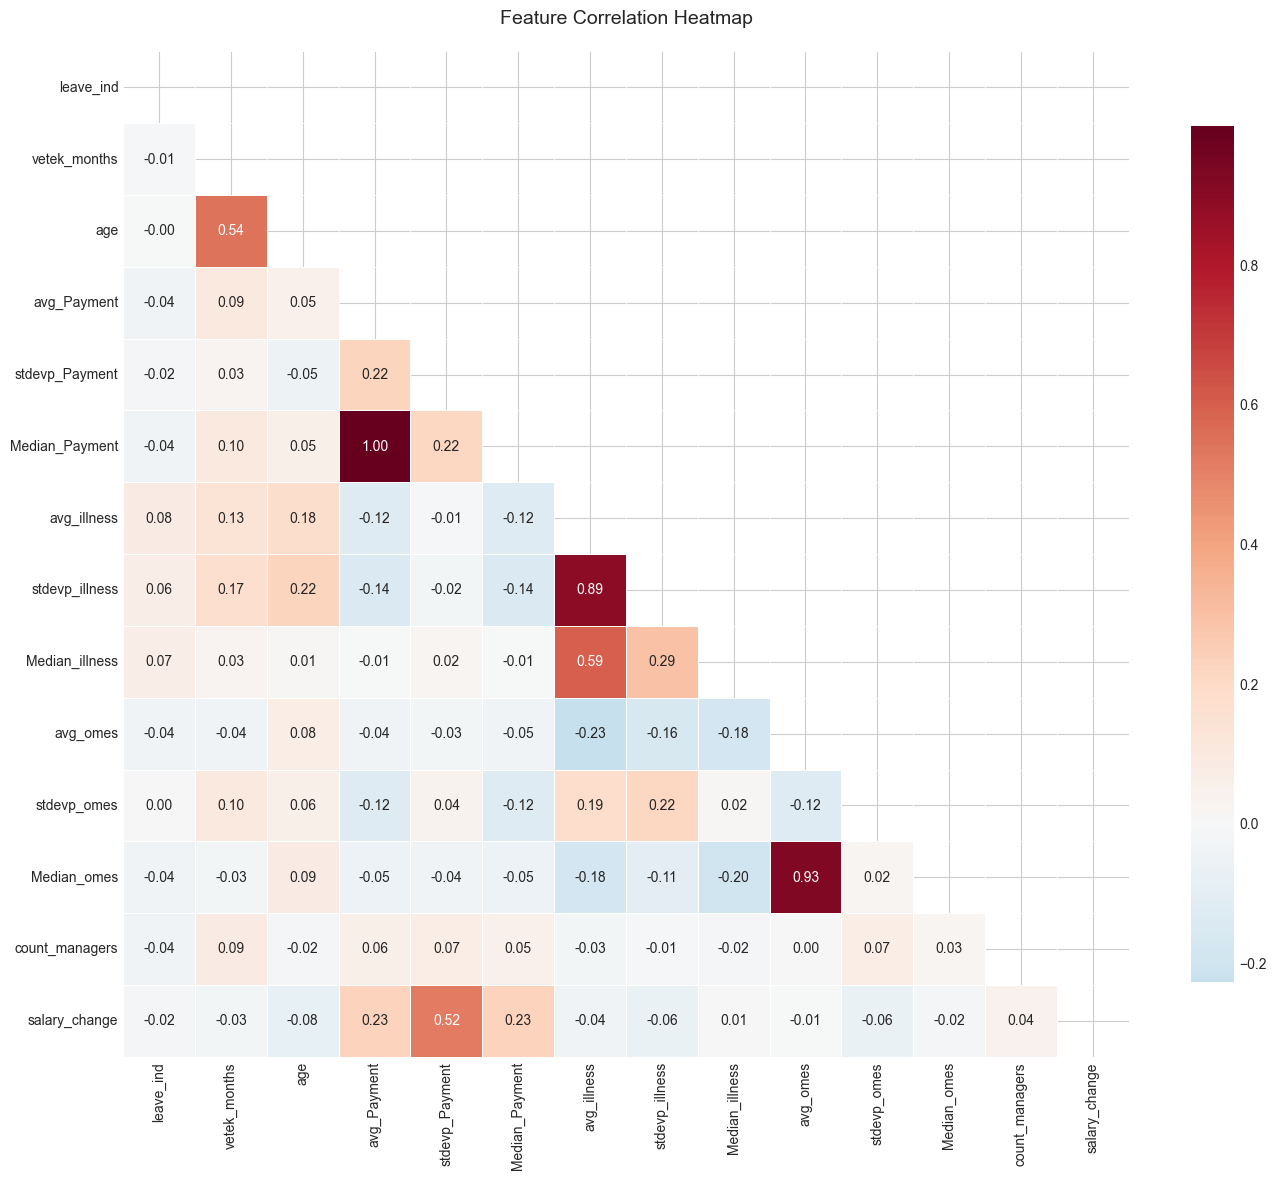

In [50]:
# Select numeric columns for correlation
corr_cols = ['leave_ind'] + numeric_cols

corr_matrix = updated_df[corr_cols].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

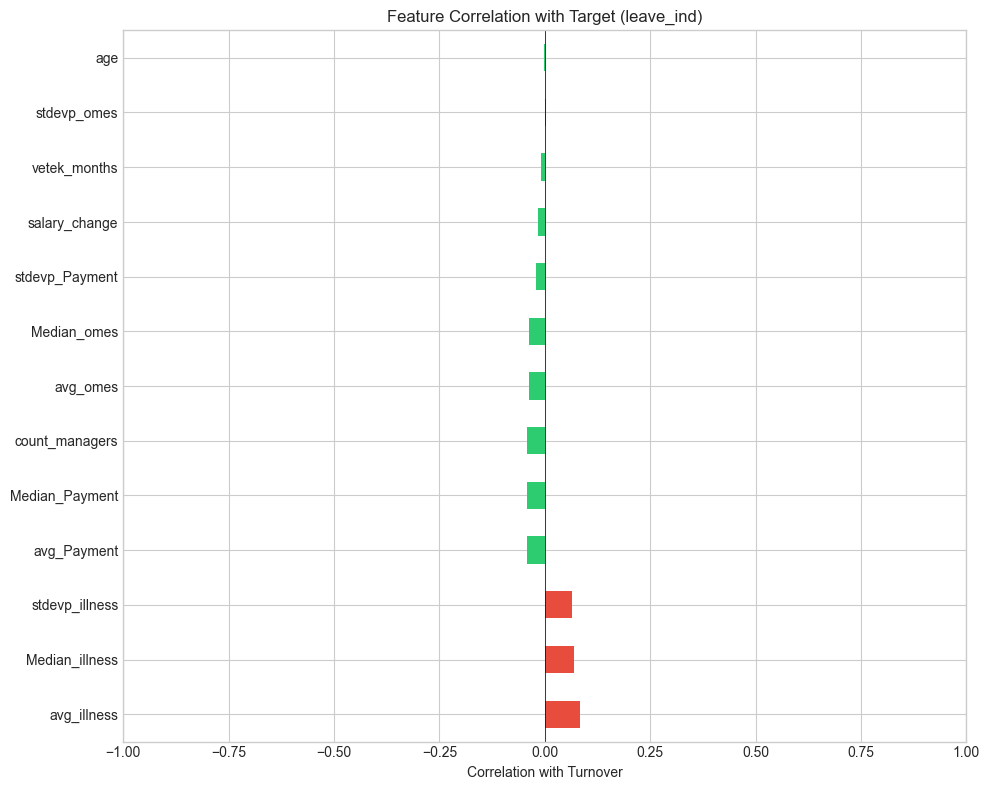


Top Positive Correlations (Higher = More Likely to Leave):
avg_illness       0.083947
Median_illness    0.068741
stdevp_illness    0.064890
stdevp_omes       0.002784
Name: leave_ind, dtype: float64

Top Negative Correlations (Higher = More Likely to Stay):
avg_Payment      -0.042399
Median_Payment   -0.041922
count_managers   -0.041232
avg_omes         -0.038700
Median_omes      -0.037013
Name: leave_ind, dtype: float64


In [ ]:
# Correlation with target
target_corr = corr_matrix['leave_ind'].drop('leave_ind').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Correlation with Turnover')
ax.set_title('Feature Correlation with Target (leave_ind)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.show()

print("\nTop Positive Correlations (Higher = More Likely to Leave):")
print(target_corr[target_corr > 0].head())
print("\nTop Negative Correlations (Higher = More Likely to Stay):")
print(target_corr[target_corr < 0].head())

## 6. Time-Series Analysis (Employee Tracking)

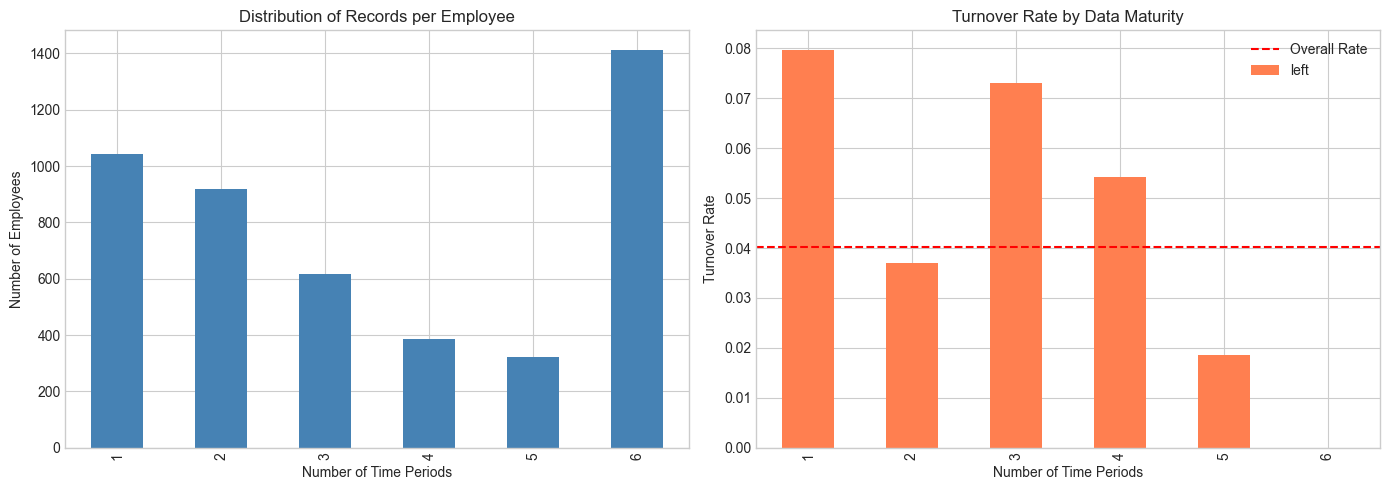


Records per Employee Statistics:
count    4700.000000
mean        3.480638
std         1.977810
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max         6.000000
dtype: float64


In [53]:
# Analyze number of records per employee
records_per_emp = updated_df.groupby('fictive_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of records per employee
ax = axes[0]
records_per_emp.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Number of Time Periods')
ax.set_ylabel('Number of Employees')
ax.set_title('Distribution of Records per Employee')

# Turnover rate by number of records
ax = axes[1]
emp_records = updated_df.groupby('fictive_id').agg({'leave_ind': 'last', 'fictive_id': 'count'})
emp_records.columns = ['left', 'num_periods']
turnover_by_periods = emp_records.groupby('num_periods')['left'].mean()

turnover_by_periods.plot(kind='bar', ax=ax, color='coral')
ax.set_xlabel('Number of Time Periods')
ax.set_ylabel('Turnover Rate')
ax.set_title('Turnover Rate by Data Maturity')
ax.axhline(y=emp_records['left'].mean(), color='red', linestyle='--', label='Overall Rate')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nRecords per Employee Statistics:")
print(records_per_emp.describe())

## 7. Age & Tenure Analysis

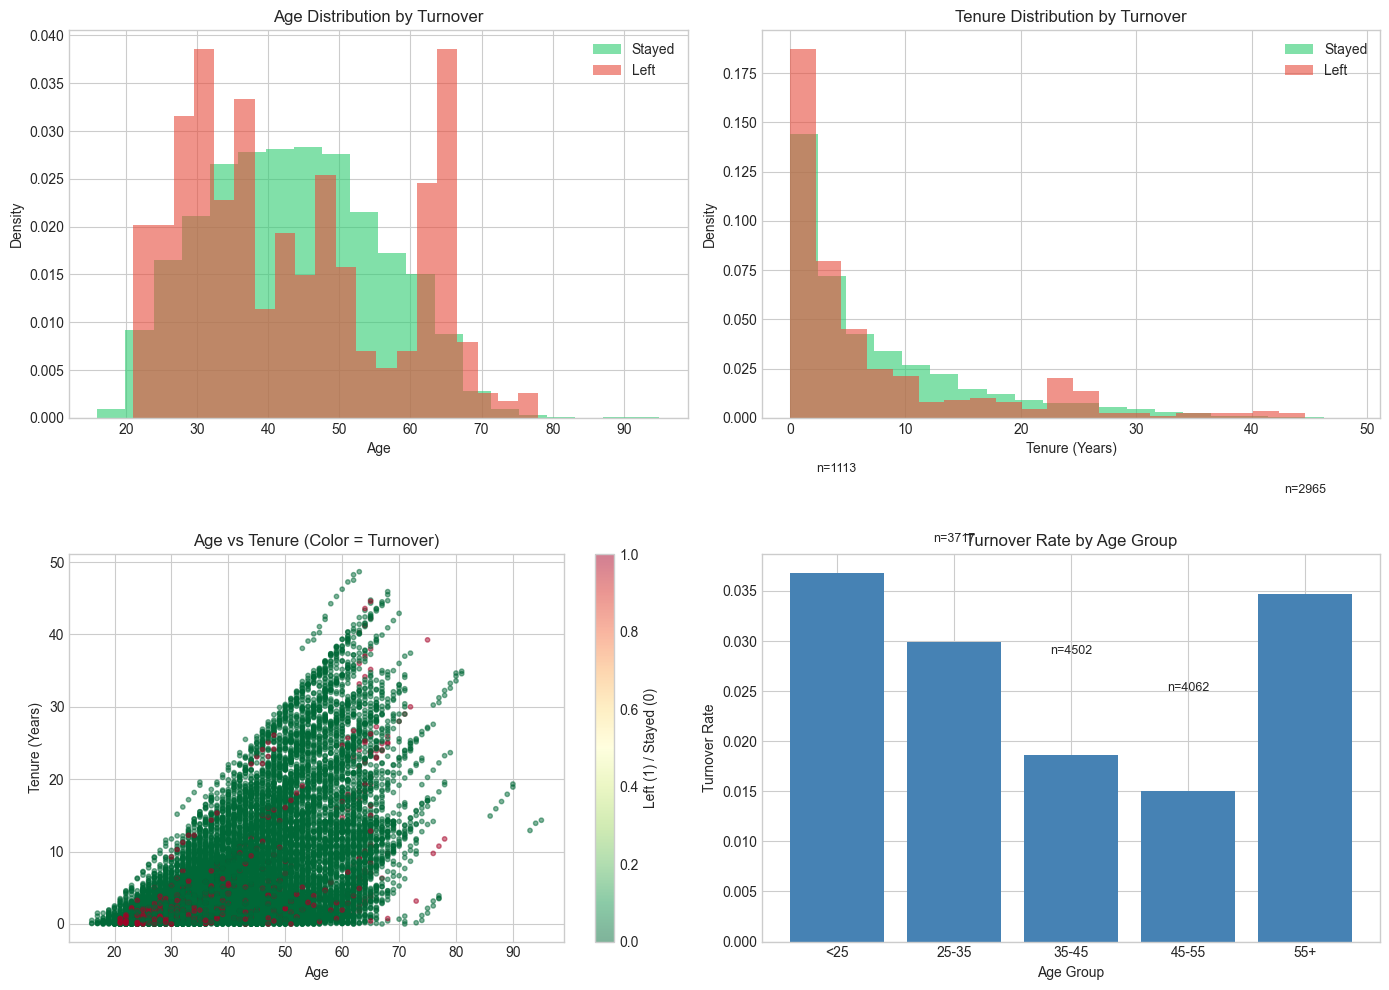

In [54]:
# Age distribution by turnover
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
ax = axes[0, 0]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = updated_df[updated_df['leave_ind'] == target]['age']
    ax.hist(data, bins=20, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('Age Distribution by Turnover')
ax.legend()

# Tenure distribution
ax = axes[0, 1]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = updated_df[updated_df['leave_ind'] == target]['vetek_months'] / 12  # Convert to years
    ax.hist(data, bins=20, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Tenure (Years)')
ax.set_ylabel('Density')
ax.set_title('Tenure Distribution by Turnover')
ax.legend()

# Age vs Tenure scatter
ax = axes[1, 0]
scatter = ax.scatter(updated_df['age'], updated_df['vetek_months']/12, c=updated_df['leave_ind'], 
                     cmap='RdYlGn_r', alpha=0.5, s=10)
ax.set_xlabel('Age')
ax.set_ylabel('Tenure (Years)')
ax.set_title('Age vs Tenure (Color = Turnover)')
plt.colorbar(scatter, ax=ax, label='Left (1) / Stayed (0)')

# Turnover rate by age group
ax = axes[1, 1]
updated_df['age_group'] = pd.cut(updated_df['age'], bins=[0, 25, 35, 45, 55, 100], 
                         labels=['<25', '25-35', '35-45', '45-55', '55+'])
turnover_by_age = updated_df.groupby('age_group', observed=True)['leave_ind'].agg(['mean', 'count'])

bars = ax.bar(range(len(turnover_by_age)), turnover_by_age['mean'], color='steelblue')
ax.set_xticks(range(len(turnover_by_age)))
ax.set_xticklabels(turnover_by_age.index)
ax.set_xlabel('Age Group')
ax.set_ylabel('Turnover Rate')
ax.set_title('Turnover Rate by Age Group')

for i, (bar, count) in enumerate(zip(bars, turnover_by_age['count'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'n={count}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Salary Analysis

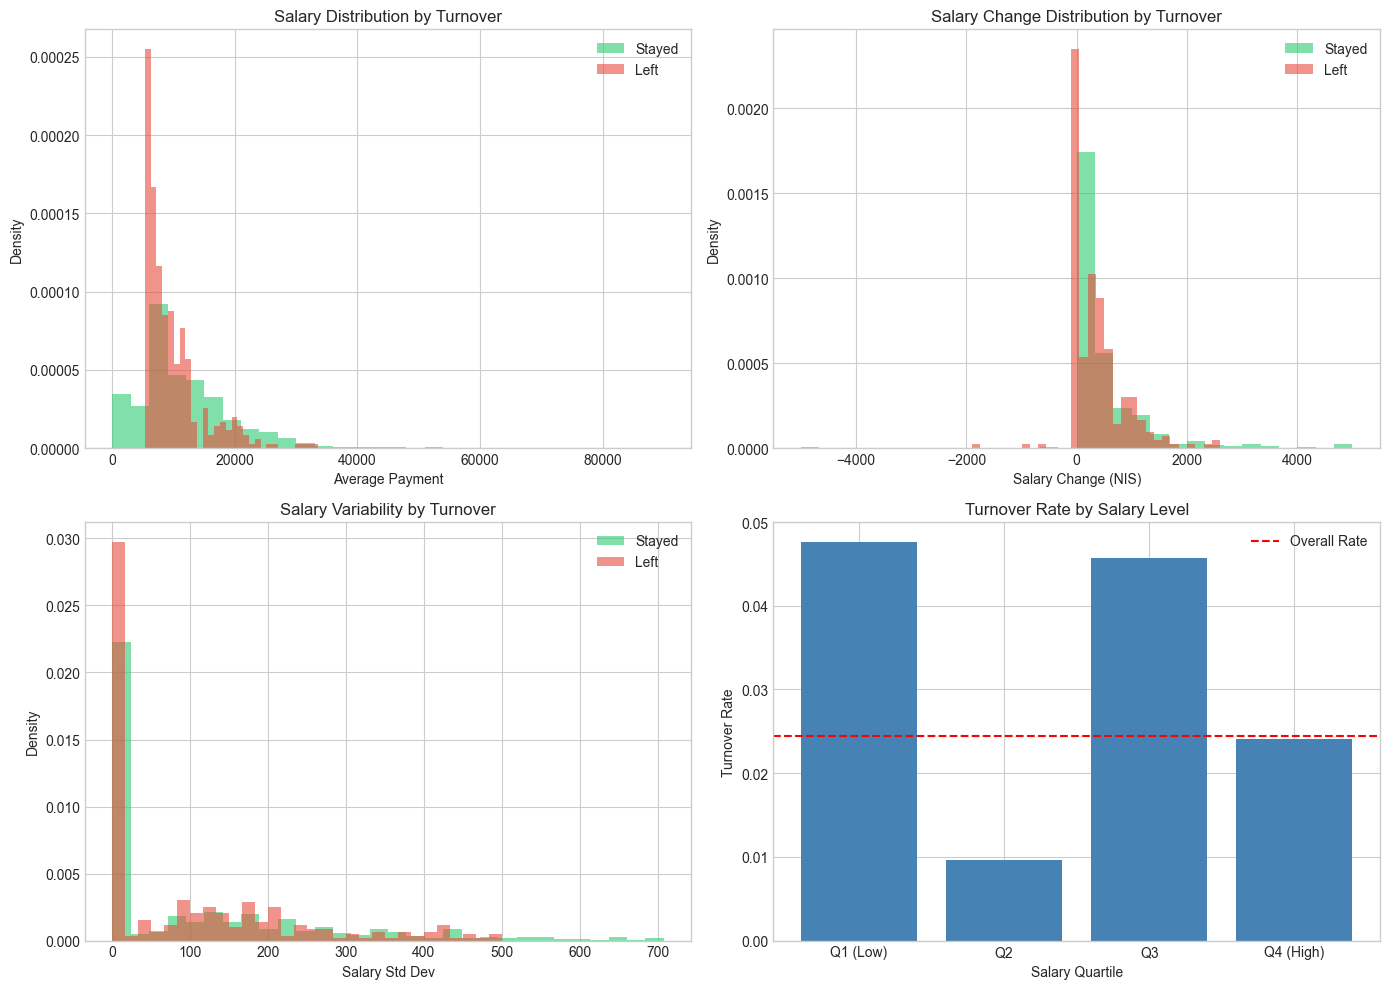

In [55]:
# Salary analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Average Payment distribution
ax = axes[0, 0]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = updated_df[updated_df['leave_ind'] == target]['avg_Payment'].dropna()
    ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Average Payment')
ax.set_ylabel('Density')
ax.set_title('Salary Distribution by Turnover')
ax.legend()

# Salary change distribution
ax = axes[0, 1]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = updated_df[updated_df['leave_ind'] == target]['salary_change'].dropna()
    # Clip for visualization
    data = data.clip(-5000, 5000)
    ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Salary Change (NIS)')
ax.set_ylabel('Density')
ax.set_title('Salary Change Distribution by Turnover')
ax.legend()

# Salary variability (stddev)
ax = axes[1, 0]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = updated_df[updated_df['leave_ind'] == target]['stdevp_Payment'].dropna()
    data = data[data < data.quantile(0.95)]  # Remove extreme outliers
    ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Salary Std Dev')
ax.set_ylabel('Density')
ax.set_title('Salary Variability by Turnover')
ax.legend()

# Turnover by salary quartile
ax = axes[1, 1]
updated_df['salary_quartile'] = pd.qcut(updated_df['avg_Payment'].fillna(updated_df['avg_Payment'].median()), 
                                         q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
turnover_by_salary = updated_df.groupby('salary_quartile', observed=True)['leave_ind'].agg(['mean', 'count'])

bars = ax.bar(range(len(turnover_by_salary)), turnover_by_salary['mean'], color='steelblue')
ax.set_xticks(range(len(turnover_by_salary)))
ax.set_xticklabels(turnover_by_salary.index)
ax.set_xlabel('Salary Quartile')
ax.set_ylabel('Turnover Rate')
ax.set_title('Turnover Rate by Salary Level')
ax.axhline(y=updated_df['leave_ind'].mean(), color='red', linestyle='--', label='Overall Rate')
ax.legend()

plt.tight_layout()
plt.show()

## 9. Workload & Sick Days Analysis

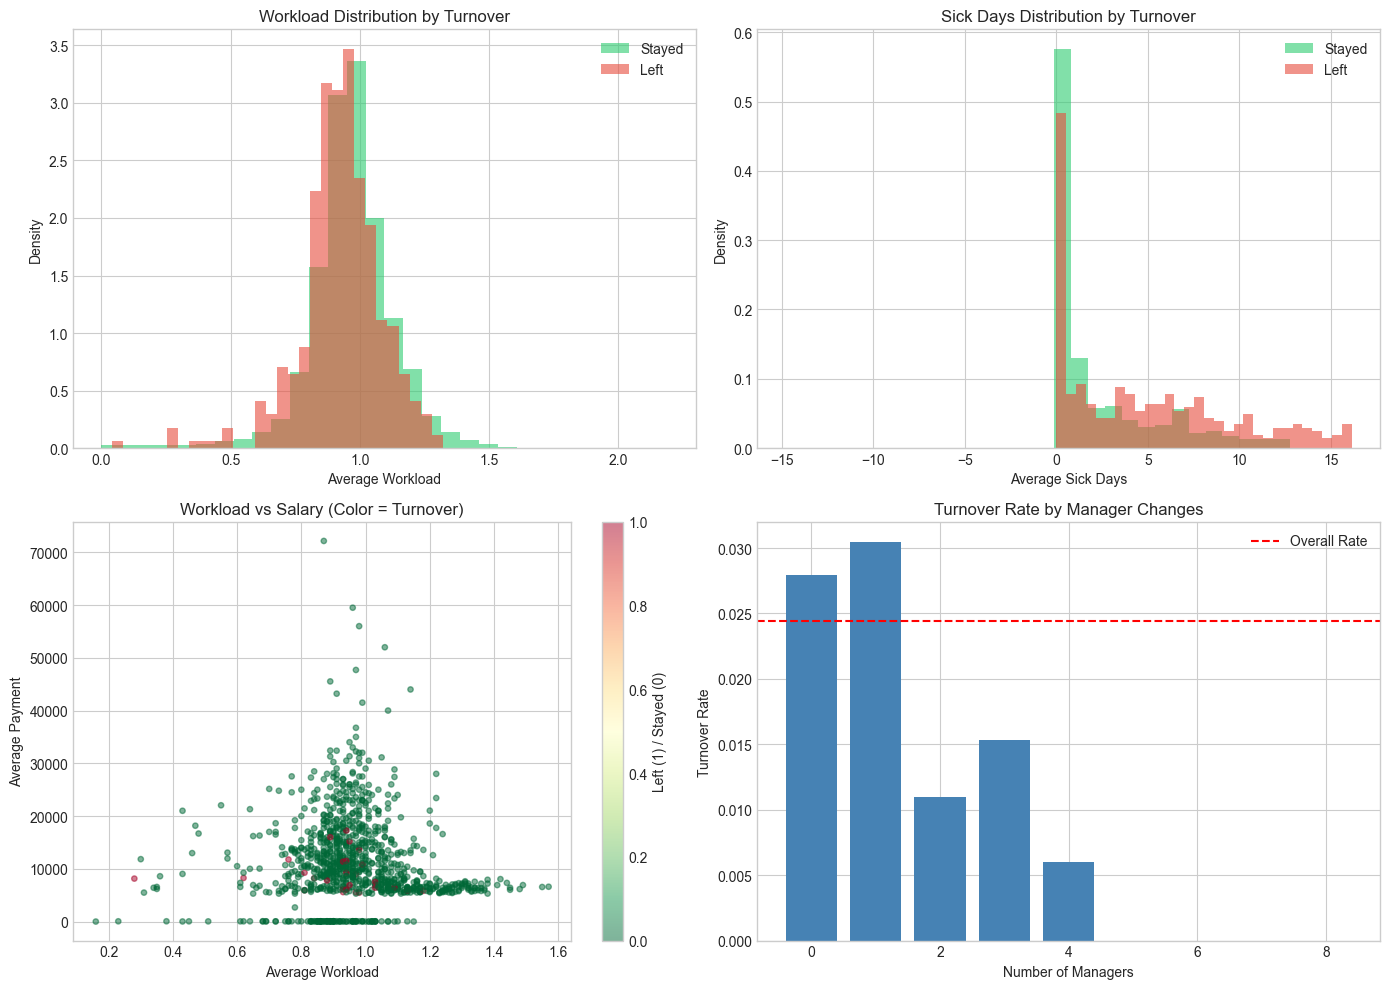

In [56]:
# Workload and illness patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Average Workload
ax = axes[0, 0]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = updated_df[updated_df['leave_ind'] == target]['avg_omes'].dropna()
    ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Average Workload')
ax.set_ylabel('Density')
ax.set_title('Workload Distribution by Turnover')
ax.legend()

# Average Sick Days
ax = axes[0, 1]
for target, color, label in [(0, '#2ecc71', 'Stayed'), (1, '#e74c3c', 'Left')]:
    data = updated_df[updated_df['leave_ind'] == target]['avg_illness'].dropna()
    data = data[data < data.quantile(0.95)]  # Remove extreme outliers
    ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel('Average Sick Days')
ax.set_ylabel('Density')
ax.set_title('Sick Days Distribution by Turnover')
ax.legend()

# Workload vs Salary scatter
ax = axes[1, 0]
sample = updated_df.dropna(subset=['avg_omes', 'avg_Payment']).sample(min(1000, len(updated_df)))
scatter = ax.scatter(sample['avg_omes'], sample['avg_Payment'], 
                     c=sample['leave_ind'], cmap='RdYlGn_r', alpha=0.5, s=15)
ax.set_xlabel('Average Workload')
ax.set_ylabel('Average Payment')
ax.set_title('Workload vs Salary (Color = Turnover)')
plt.colorbar(scatter, ax=ax, label='Left (1) / Stayed (0)')

# Manager changes vs turnover
ax = axes[1, 1]
turnover_by_managers = updated_df.groupby('count_managers')['leave_ind'].agg(['mean', 'count'])
turnover_by_managers = turnover_by_managers[turnover_by_managers['count'] > 10]  # Filter small groups

ax.bar(turnover_by_managers.index, turnover_by_managers['mean'], color='steelblue')
ax.set_xlabel('Number of Managers')
ax.set_ylabel('Turnover Rate')
ax.set_title('Turnover Rate by Manager Changes')
ax.axhline(y=updated_df['leave_ind'].mean(), color='red', linestyle='--', label='Overall Rate')
ax.legend()

plt.tight_layout()
plt.show()